# **5. Spatio-Temporal Long Short-Term Memory (ST-LSTM)**

El modelo ST-LSTM es una arquitectura de aprendizaje profundo diseñada específicamente para el modelado espacio-temporal del dengue a nivel departamental. Su propósito principal es capturar la compleja dinámica de transmisión de la enfermedad mediante la memoria selectiva de largo plazo de las redes LSTM, fusionando dos señales fundamentales y asincrónicas: los componentes epidemiológicos y los factores climáticos.

```text
         [ Input Tensor: (B, T, N, Features) ]
                          |
          +---------------+---------------+
          |                               |
  [ Epi Features ]               [ Clim Features ]
          |                               |
  Linear Projection              Linear Projection
          |                               |
    LSTM Encoder                   LSTM Encoder
    (L capas apiladas)             (L capas apiladas)
          |                               |
  Adaptive Lag Module          Adaptive Lag Module
          |                               |
          +---------------+---------------+
                          |
                Cross-Modal Attention
                          |
                    Dropout & FC
                          |
         [ Output: Horizon Predictions (B, H, N) ]
```

La arquitectura del modelo procesa los datos secuencialmente a través de cuatro componentes. Primero, el **ModalEncoder** proyecta linealmente las variables epidemiológicas y climáticas de cada departamento a una dimensión común ($d_{\text{model}}$), alimentando dos stacks independientes de LSTMs apiladas que capturan dependencias temporales de largo alcance mediante sus compuertas de olvido, entrada y salida. Después, el **AdaptiveLagModule** proyecta la ventana histórica (`max_lag`) y, mediante Softmax y un producto tensorial (`torch.einsum`), pondera dinámicamente qué semanas pasadas son más relevantes para cada nodo, produciendo un contexto comprimido por departamento. Luego, el **CrossModalAttention** fusiona ambos streams alineando la susceptibilidad biológica con el estrés ambiental, usando el contexto epidemiológico como *Query* ($Q$) y el climático como *Key* ($K$) y *Value* ($V$) mediante atención multi-cabeza. Finalmente, la **Dimensión de Salida** emplea una capa lineal (`nn.Linear`) que mapea esta representación fusionada para predecir la incidencia del dengue a un horizonte de cuatro semanas por departamento.

## **5.1. Librerías**

In [1]:
import os
import copy
import random
import warnings
import optuna
import shap

import numpy as np
import pandas as pd
import scipy.stats as st
import geopandas as gpd
from shapely.geometry import Point

from spatialkfold.clusters import spatial_kfold_clusters
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import math
import sys
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/moon/miniconda3/envs/deeplearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **5.2. Configuración & Reproducibilidad**

Se establece el entorno y las configuraciones de reproducibilidad del proyecto, inicializando las semillas globales (`SEEDS`), el número de pliegues espaciales (`N_SPATIAL_FOLDS = 5`) y los intentos de optimización con Optuna.

In [2]:
SEEDS = [42, 123, 2024]
N_SPATIAL_FOLDS = 5     
N_OPTUNA_TRIALS = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("medium")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Python:", sys.version)
print("Torch:",  torch.__version__)
print("Numpy:",  np.__version__)
print("Pandas:", pd.__version__)
print("GeoPandas:", gpd.__version__)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"  Seed fijada: {seed}")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
Torch: 2.12.0.dev20260407+cu128
Numpy: 2.4.3
Pandas: 3.0.2
GeoPandas: 1.1.3


## **5.3. Carga de Datos & Feature Engineering**

Se inicializan las rutas del proyecto y se carga el conjunto de datos principal (`df_full.csv`), indexando la columna temporal en formato `datetime` para posteriormente ordenar de forma ascendente los registros por departamento y fecha, asegurando así la consistencia cronológica necesaria para el análisis de las series de tiempo.

In [4]:
from pathlib import Path

BASE_PATH = Path('/home/moon/DEEP/PF/PF_DG/MODELOS/LSTM_CV')
BASE_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("/home/moon/DEEP/PF/PF_DG/DATA/Bases_Datos/df_full.csv")
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])
df = df.sort_values(["departamento", "fecha_inicio"]).reset_index(drop=True)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 21664 | Columnas: 54


,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


Se realiza la ingeniería de características mapeando cíclicamente las semanas epidemiológicas mediante funciones seno y coseno para capturar la estacionalidad del dengue, definimos los conjuntos de variables predictoras epidemiológicas y climáticas con sus respectivos rezagos históricos, y aplicamos una transformación logarítmica (`log1p`) sobre la incidencia para mitigar el sesgo provocado por los picos extremos de los brotes.

In [5]:
df["semana"] = df["semana"].astype(int)
df["ano"]    = df["fecha_inicio"].dt.year

weeks_per_year   = df.groupby("ano")["semana"].transform("max")
df["week_norm"]  = df["semana"] / weeks_per_year
df["week_sin"]   = np.sin(2 * np.pi * df["week_norm"])
df["week_cos"]   = np.cos(2 * np.pi * df["week_norm"])

EPIFEATURES = [
    "inc_lag_1","inc_lag_2","inc_lag_3","inc_lag_4",
    "inc_lag_8","inc_lag_12","inc_lag_20",
    "poblacion","prop_rural","week_sin","week_cos"
]
CLIMFEATURES = [
    "temp_lag_1","temp_lag_2","temp_lag_4","temp_lag_8","temp_lag_12","temp_lag_20",
    "humedad_lag_1","humedad_lag_2","humedad_lag_4","humedad_lag_8","humedad_lag_12","humedad_lag_20",
    "precip_lag_1","precip_lag_2","precip_lag_4","precip_lag_8","precip_lag_12","precip_lag_20",
]
FEATURES = EPIFEATURES + CLIMFEATURES

df["incidencia_log"] = np.log1p(df["incidencia"])
TARGET = "incidencia_log"
N_EPI  = len(EPIFEATURES)
N_CLIM = len(CLIMFEATURES)

print(f"EpiFeatures : {N_EPI}")
print(f"ClimFeatures: {N_CLIM}")
print(f"Total       : {len(FEATURES)} | Target: {TARGET}")

departments = sorted(df["departamento"].unique())
dept_to_idx = {d: i for i, d in enumerate(departments)}
idx_to_dept = {i: d for d, i in dept_to_idx.items()}
NUM_NODES   = len(departments)
print(f"NUM_NODES: {NUM_NODES}")
print("Departamentos:", departments)

EpiFeatures : 11
ClimFeatures: 18
Total       : 29 | Target: incidencia_log
NUM_NODES: 32
Departamentos: ['Amazonas', 'Antioquia', 'Arauca', 'Atlantico', 'Bogota d.c.', 'Bolivar', 'Boyaca', 'Caldas', 'Caqueta', 'Casanare', 'Cauca', 'Cesar', 'Choco', 'Cordoba', 'Cundinamarca', 'Guainia', 'Guajira', 'Guaviare', 'Huila', 'Magdalena', 'Meta', 'Narino', 'Norte De Santander', 'Putumayo', 'Quindio', 'Risaralda', 'Santander', 'Sucre', 'Tolima', 'Valle Del Cauca', 'Vaupes', 'Vichada']


## **5.4. Construcción de Folds Espaciales**

Se estructura la partición geográfica del modelo construyendo un objeto `GeoDataFrame` a partir de los centroides calculados para cada departamento, el cual se proyecta a coordenadas UTM para evitar las distorsiones métricas del sistema de grados cartesianos. Posteriormente, se aplica la función `spatial_kfold_clusters` mediante un algoritmo de KMeans para agrupar los territorios en cinco pliegues espaciales contiguos, mapeando estas asignaciones de vuelta al conjunto de datos principal y generando una visualización cartográfica que valida la distribución regional y previene la fuga de información por proximidad geográfica durante la validación cruzada.

In [6]:
import geopandas as gpd

cent = pd.read_csv('/home/moon/DEEP/PF/PF_DG/DATA/Covariables/centroides_departamentos.csv')

dept_coords = (
    cent.groupby("departamento")
      .agg(
          lat=("latitud", "mean"),
          lon=("longitud", "mean")
      )
      .reset_index()
)

geometry = gpd.points_from_xy(
    dept_coords["lon"],
    dept_coords["lat"]
)

gdf_depts = gpd.GeoDataFrame(
    dept_coords,
    geometry=geometry,
    crs="EPSG:4326"
)

gdf_depts_utm = gdf_depts.to_crs(
    gdf_depts.estimate_utm_crs()
)

gdf_depts_folded = spatial_kfold_clusters(
    gdf=gdf_depts_utm,
    name="departamento",
    nfolds=N_SPATIAL_FOLDS,
    algorithm="kmeans",
    random_state=42
)

print("Columnas resultado:", gdf_depts_folded.columns.tolist())
print(gdf_depts_folded[["departamento","folds"]].sort_values("folds").to_string(index=False))

Columnas resultado: ['departamento', 'lat', 'lon', 'geometry', 'folds']
      departamento  folds
         Atlantico      1
           Bolivar      1
           Cordoba      1
             Cesar      1
             Sucre      1
Norte De Santander      1
         Magdalena      1
           Guajira      1
           Caqueta      2
             Huila      2
            Narino      2
          Putumayo      2
             Cauca      2
      Cundinamarca      3
       Bogota d.c.      3
         Antioquia      3
            Tolima      3
           Quindio      3
         Risaralda      3
         Santander      3
            Boyaca      3
            Caldas      3
             Choco      3
              Meta      3
   Valle Del Cauca      3
          Guaviare      4
            Vaupes      4
          Amazonas      4
           Guainia      5
          Casanare      5
            Arauca      5
           Vichada      5


In [7]:
fold_map = gdf_depts_folded.set_index("departamento")["folds"].to_dict()
df["spatial_fold"] = df["departamento"].map(fold_map)

print("\nObservaciones por fold espacial:")
print(df.groupby("spatial_fold")["departamento"].nunique().rename("n_departamentos"))
print("\nDepartamentos por fold:")
for fold_id, grp in df.groupby("spatial_fold")["departamento"].unique().items():
    print(f"  Fold {fold_id}: {sorted(grp)}")


Observaciones por fold espacial:
spatial_fold
1     8
2     5
3    12
4     3
5     4
Name: n_departamentos, dtype: int64

Departamentos por fold:
  Fold 1: ['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', 'Guajira', 'Magdalena', 'Norte De Santander', 'Sucre']
  Fold 2: ['Caqueta', 'Cauca', 'Huila', 'Narino', 'Putumayo']
  Fold 3: ['Antioquia', 'Bogota d.c.', 'Boyaca', 'Caldas', 'Choco', 'Cundinamarca', 'Meta', 'Quindio', 'Risaralda', 'Santander', 'Tolima', 'Valle Del Cauca']
  Fold 4: ['Amazonas', 'Guaviare', 'Vaupes']
  Fold 5: ['Arauca', 'Casanare', 'Guainia', 'Vichada']


In [8]:
fig, ax = plt.subplots(figsize=(7, 9))
for fold_id in range(N_SPATIAL_FOLDS):
    sub = gdf_depts_folded[gdf_depts_folded["folds"] == fold_id]
    sub.plot(ax=ax, markersize=120, label=f"Fold {fold_id}")
    for _, row in sub.iterrows():
        ax.annotate(row["departamento"], xy=(row.geometry.x, row.geometry.y),
                    fontsize=5, ha="center", va="bottom")
ax.set_title(f"Folds espaciales KMeans (k={N_SPATIAL_FOLDS}) — Departamentos Colombia",
             fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/spatial_folds_map.png", dpi=150)
plt.show()

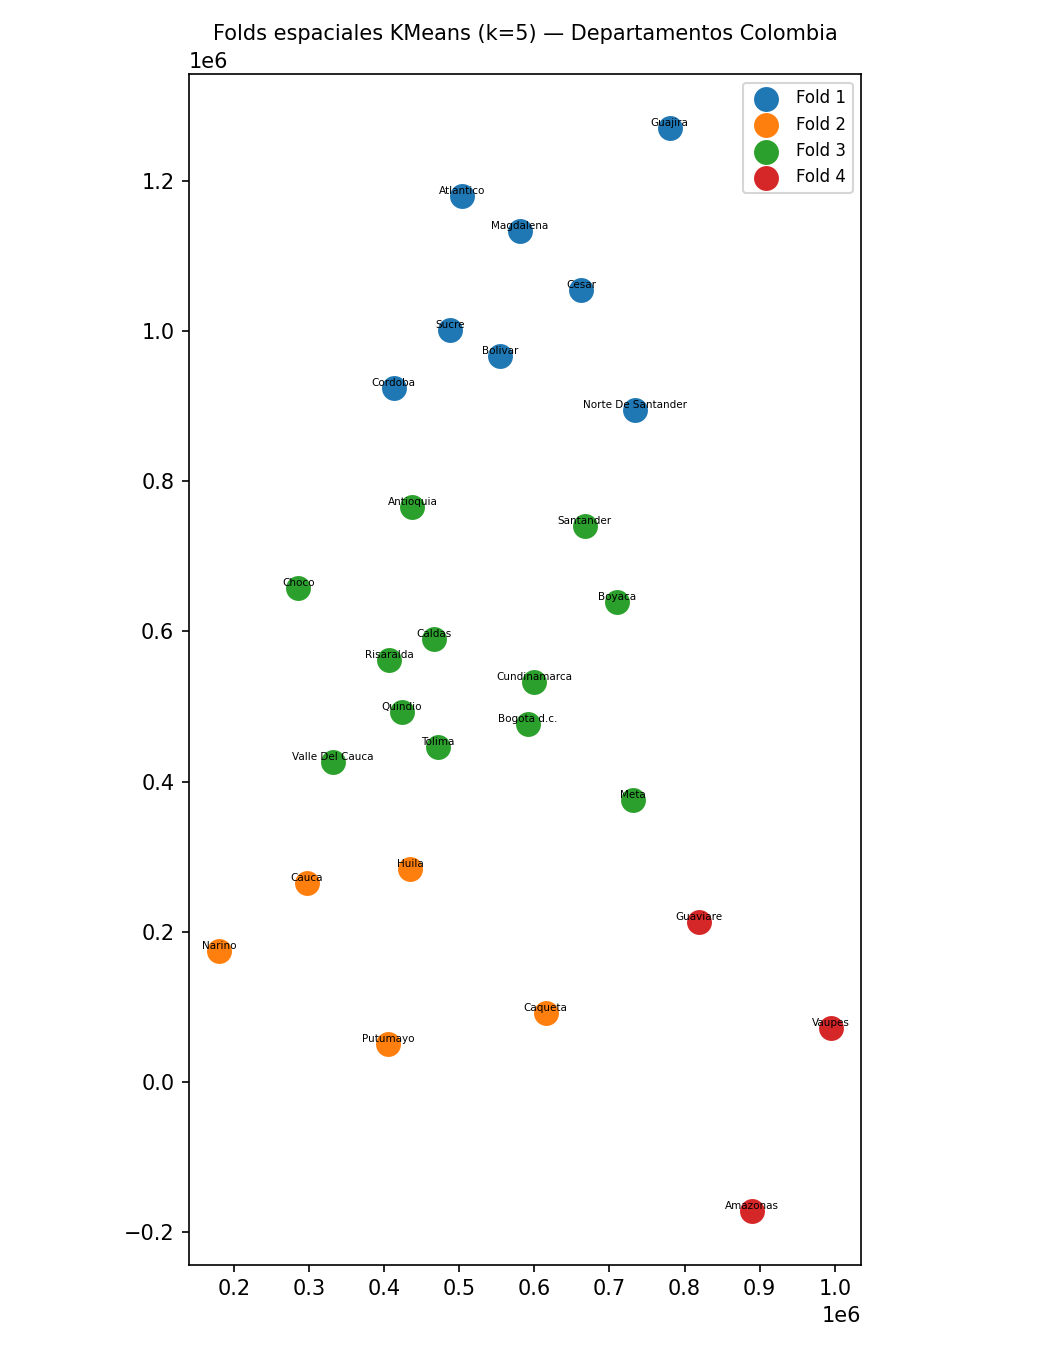

In [54]:
from PIL import Image
Image.open(f"{BASE_PATH}/spatial_folds_map.png")

El mapa de folds espaciales KMeans ($k=5$) ilustra la partición geográfica de los departamentos utilizada en la validación cruzada espacial. El **Fold 1** (azul) agrupa los departamentos de la región Caribe y norte del país —Atlántico, Magdalena, Cesar, Sucre, Bolívar, Córdoba, Guajira y Norte de Santander—, conformando un clúster geográficamente cohesivo de alta densidad poblacional y transmisión endémica de dengue en la franja costera norte. El **Fold 2** (naranja) reúne departamentos del suroccidente y sur del país —Cauca, Huila, Nariño, Caquetá y Putumayo—, caracterizados por su posición periférica, relieve montañoso y dinámica epidémica particular influenciada por factores ambientales del Pacífico y la Amazonia occidental. El **Fold 3** (verde) es el más heterogéneo del conjunto, abarcando el eje andino central y oriental —Antioquia, Chocó, Caldas, Risaralda, Quindío, Tolima, Valle del Cauca, Cundinamarca, Bogotá d.c., Boyacá, Santander y Meta—, que concentra la mayor parte de la población urbana del país y los departamentos de mayor incidencia acumulada histórica. El **Fold 4** (rojo) agrupa los departamentos amazónicos de menor densidad poblacional y mayor aislamiento geográfico —Amazonas, Vaupés y Guaviare—, que presentan las dinámicas epidémicas más irregulares y variables del sistema. La distribución espacial de los folds refleja que el algoritmo KMeans captura patrones geográficos interpretables —regiones naturales y corredores de transmisión— que corresponden a unidades epidemiológicas funcionalmente diferenciadas, validando la idoneidad de esta partición para evaluar la generalización espacial de los modelos.

## **5.5. Esquema de Validación Espacio-Temporal**

Esta sección define la estrategia de validación cruzada anidada (*Nested Cross-Validation*) para evaluar el modelo bajo un enfoque espacio-temporal estricto y robusto. Mediante las funciones `create_outer_folds` y `create_inner_folds`, el código fragmenta cronológicamente los datos en bloques externos de prueba (años 2022 a 2024) y bloques internos de validación (años 2019 a 2021) para simular escenarios reales de predicción a futuro. Finalmente, integra el estimador `LeaveOneGroupOut` de scikit-learn, configurando un esquema donde cada ciclo de optimización (*tuning*) cruza estas ventanas de tiempo con las regiones geográficas previas, garantizando que el algoritmo sea evaluado aislando grupos espaciales completos para medir su capacidad de generalización en territorios no observados.

In [9]:
def create_outer_folds(df, date_col="fecha_inicio"):
    folds = []
    for test_year in [2022, 2023, 2024]:
        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()
        folds.append({"test_year": test_year, "train_df": train_df, "test_df": test_df})
    return folds

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):
    inner_folds = []
    for val_year in val_years:
        inner_train = train_df[train_df["fecha_inicio"].dt.year <  val_year].copy()
        inner_val   = train_df[train_df["fecha_inicio"].dt.year == val_year].copy()
        inner_folds.append({"val_year": val_year,
                             "inner_train": inner_train,
                             "inner_val":   inner_val})
    return inner_folds

outer_folds = create_outer_folds(df)

LOGO = LeaveOneGroupOut()

print(f"Outer folds temporales: {len(outer_folds)}")
print(f"Inner folds temporales: 3 (2019, 2020, 2021)")
print(f"Folds espaciales: {N_SPATIAL_FOLDS}")
print(f"Total iteraciones tuning por trial: {3 * N_SPATIAL_FOLDS} (inner × spatial)")

Outer folds temporales: 3
Inner folds temporales: 3 (2019, 2020, 2021)
Folds espaciales: 5
Total iteraciones tuning por trial: 15 (inner × spatial)


## **5.6. Ventanas de Tiempo & Escalamiento**

Se reestructuran los datos en ventanas deslizantes tridimensionales y posteriormente se realiza una normalización estadística. La función `create_windows` utiliza tablas de pivote para transformar el DataFrame plano en tensores organizados por tiempo, nodos (departamentos) y características, generando secuencias históricas de entrenamiento (`window_size=12`) emparejadas con sus respectivos horizontes de predicción futura (`horizon=4`). Por otro lado, la función `scale_data` implementa un objeto `RobustScaler` que se ajusta exclusivamente con los datos de entrenamiento tras aplanar temporalmente las dimensiones, escalando las señales basándose en percentiles e rangos intercuartílicos para neutralizar el impacto de valores atípicos extremos antes de devolver los arreglos con su forma espacio-temporal original.

In [10]:
def create_windows(df, features, target, window_size=12, horizon=4):
    pivot_features = []
    for feat in features:
        pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                               values=feat).sort_index()
        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)   # (T, nodes, n_features)

    target_pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                                  values=target).sort_index()
    y_all  = target_pivot.values
    dates  = target_pivot.index.values

    X, y, base_dates = [], [], []
    for i in range(len(dates) - window_size - horizon + 1):
        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(base_dates)


def scale_data(X_train, X_val):
    scaler = RobustScaler()
    nf     = X_train.shape[-1]
    X_train_2d = X_train.reshape(-1, nf)
    scaler.fit(X_train_2d)
    X_train_sc = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val_sc   = scaler.transform(X_val.reshape(-1, nf)).reshape(X_val.shape)
    return X_train_sc, X_val_sc, scaler

## **5.7. Dataset, Early Stopping & Funciones de Entrenamiento**

Se define la infraestructura de entrenamiento del ST-LSTM mediante cuatro componentes: `STLSTMDataset` encapsula los tensores de entrada y salida en un objeto compatible con `DataLoader`; `EarlyStopping` monitorea la pérdida de validación y detiene el entrenamiento si no mejora tras `patience=20` épocas consecutivas para prevenir sobreajuste; `train_one_epoch` ejecuta una época completa de optimización con propagación hacia atrás y recorte de gradientes (`clip_grad_norm_`) para estabilizar el aprendizaje; y `validate_one_epoch` evalúa el modelo en modo inferencia sin actualizar pesos, retornando la pérdida promedio sobre el conjunto de validación.

In [11]:
class STLSTMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class EarlyStopping:
    def __init__(self, patience=20):
        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False
    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_one_epoch(model, dataloader, criterion, optimizer, device, n_epi, n_clim):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        pred, _ = model(X_batch, n_epi, n_clim)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def validate_one_epoch(model, dataloader, criterion, device, n_epi, n_clim):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            pred, _ = model(X_batch, n_epi, n_clim)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(dataloader)

## **5.8. Métricas**

Se consolida el módulo de evaluación estadística del proyecto sobre los arreglos aplanados de los valores reales y predichos. Más allá de los indicadores tradicionales de magnitud de error como RMSE y MAE, se integra coeficientes hidrológicos y ecológicos avanzados como la eficiencia de Nash-Sutcliffe (`nse`) y el índice de Kling-Gupta (`kge`) para diagnosticar sesgos estructurales y variabilidad en la serie de tiempo. Asimismo, incorpora métricas de estricto control epidemiológico como el `rmse_top10`, el cual aísla los registros que superan el percentil 90 con el fin de cuantificar de forma específica el desempeño del modelo frente a picos extremos y brotes epidémicos severos de dengue.

In [12]:
def mape(y_true, y_pred, eps=1.0):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def smape(y_true, y_pred, eps=1.0):
    num = np.abs(y_true - y_pred)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + eps
    return np.mean(num / den) * 100

def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-10)

def kge(y_true, y_pred):
    r     = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-10)
    beta  = np.mean(y_pred) / (np.mean(y_true) + 1e-10)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def skill_score(y_true, y_pred):
    mse_model = mean_squared_error(y_true, y_pred)
    mse_naive = mean_squared_error(y_true, np.full_like(y_true, np.mean(y_true)))
    return 1 - mse_model / (mse_naive + 1e-10)

def rmse_top10(y_true, y_pred, q=0.90):
    threshold = np.quantile(y_true, q)
    mask = y_true >= threshold
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def pearson_r(y_true, y_pred):
    if np.std(y_true) < 1e-10 or np.std(y_pred) < 1e-10:
        return np.nan
    return np.corrcoef(y_true, y_pred)[0, 1]

def compute_all_metrics(y_true, y_pred, prefix=""):
    yt, yp = np.array(y_true).flatten(), np.array(y_pred).flatten()
    return {
        f"{prefix}RMSE":        np.sqrt(mean_squared_error(yt, yp)),
        f"{prefix}MAE":         mean_absolute_error(yt, yp),
        f"{prefix}MAPE":        mape(yt, yp),
        f"{prefix}sMAPE":       smape(yt, yp),
        f"{prefix}NSE":         nse(yt, yp),
        f"{prefix}KGE":         kge(yt, yp),
        f"{prefix}SkillScore":  skill_score(yt, yp),
        f"{prefix}RMSE_top10":  rmse_top10(yt, yp),
        f"{prefix}Pearson_r":   pearson_r(yt, yp),
        f"{prefix}Bias":        float(np.mean(yp - yt)),
    }

print("Métricas cargadas: RMSE, MAE, MAPE, sMAPE, NSE, KGE, SkillScore, RMSE_top10, Pearson_r, Bias")

Métricas cargadas: RMSE, MAE, MAPE, sMAPE, NSE, KGE, SkillScore, RMSE_top10, Pearson_r, Bias


## **5.9. Arquitectura ST-LSTM — Spatial-Temporal LSTM**

Se define la arquitectura completa del ST-LSTM. El `AdaptiveLagModule` —compartido con el ECT— selecciona mediante atención Softmax qué semanas de la ventana histórica (`max_lag`) son más relevantes por nodo, produciendo un contexto comprimido $(B, N, D)$ vía `torch.einsum`. El `FusionAttention` —análogo al `CrossModalAttention` del ECT— fusiona ambos streams usando el contexto epidemiológico como $Q$ y el climático como $K$ y $V$ mediante Multi-Head Attention con conexión residual y normalización por capas. El `ModalLSTMEncoder` proyecta linealmente las variables de entrada a $d_{\text{hidden}}$, las procesa con un LSTM apilado de `n_layers` capas con compuertas de olvido, entrada y salida, y estabiliza la salida con `LayerNorm`; la dimensión espacial se aplana sobre el batch $(B \times N, T, F)$ para procesar todos los nodos en paralelo, restituyéndose luego a $(B, T, N, D)$. `SpatialTemporalLSTM` orquesta el flujo completo —separación de streams → encoders LSTM independientes → lag adaptativo → fusión cruzada → capa lineal— produciendo predicciones de incidencia a un horizonte de cuatro semanas por departamento con forma $(B, H, N)$. 

In [13]:
class AdaptiveLagModule(nn.Module):
    def __init__(self, d_model, max_lag=8):
        super().__init__()
        self.max_lag   = max_lag
        self.attn_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (B, T, N, D)
        B, T, N, D = x.shape
        x_lag  = x[:, -self.max_lag:, :, :]          # (B, max_lag, N, D)
        scores  = self.attn_proj(x_lag).squeeze(-1).permute(0, 2, 1)   # (B, N, max_lag)
        weights = F.softmax(scores, dim=-1)           # (B, N, max_lag)
        x_perm  = x_lag.permute(0, 2, 1, 3)          # (B, N, max_lag, D)
        context = torch.einsum("bnl,bnld->bnd", weights, x_perm)       # (B, N, D)
        return context, weights

class FusionAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.mha     = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, epi_ctx, clim_ctx):
        attn_out, attn_weights = self.mha(epi_ctx, clim_ctx, clim_ctx)
        fused = self.norm(epi_ctx + self.dropout(attn_out))
        return fused, attn_weights

class ModalLSTMEncoder(nn.Module):
    def __init__(self, in_features, d_hidden, n_layers, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_features, d_hidden)
        self.lstm = nn.LSTM(
            input_size=d_hidden,
            hidden_size=d_hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.layer_norm = nn.LayerNorm(d_hidden)

    def forward(self, x):
        x = self.input_proj(x)          
        out, _ = self.lstm(x)           
        return self.layer_norm(out)     

class SpatialTemporalLSTM(nn.Module):

    def __init__(self, num_nodes, n_epi, n_clim,
                 d_hidden=64, n_heads=4, n_layers=2,
                 horizon=4, max_lag=8, dropout=0.1):
        super().__init__()
        self.num_nodes = num_nodes
        self.horizon   = horizon
        self.d_hidden  = d_hidden

        self.epi_encoder  = ModalLSTMEncoder(n_epi,  d_hidden, n_layers, dropout)
        self.clim_encoder = ModalLSTMEncoder(n_clim, d_hidden, n_layers, dropout)

        self.lag_epi  = AdaptiveLagModule(d_hidden, max_lag=max_lag)
        self.lag_clim = AdaptiveLagModule(d_hidden, max_lag=max_lag)

        self.fusion_attn = FusionAttention(d_hidden, n_heads, dropout)

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(d_hidden, horizon)

    def forward(self, x, n_epi, n_clim):

        B, T, N, _ = x.shape

        X_epi  = x[:, :, :, :n_epi]             
        X_clim = x[:, :, :, n_epi:n_epi+n_clim]  

        X_epi_flat  = X_epi.permute(0, 2, 1, 3).reshape(B*N, T, n_epi)   
        epi_enc     = self.epi_encoder(X_epi_flat)                        
        epi_enc     = epi_enc.reshape(B, N, T, self.d_hidden).permute(0, 2, 1, 3) 

        X_clim_flat = X_clim.permute(0, 2, 1, 3).reshape(B*N, T, n_clim) 
        clim_enc    = self.clim_encoder(X_clim_flat)                     
        clim_enc    = clim_enc.reshape(B, N, T, self.d_hidden).permute(0, 2, 1, 3) 

        epi_ctx,  _            = self.lag_epi(epi_enc)   
        clim_ctx, lag_weights  = self.lag_clim(clim_enc)  

        fused, attn_weights = self.fusion_attn(epi_ctx, clim_ctx)  

        out = self.fc(self.dropout(fused)).permute(0, 2, 1)  
        return out, attn_weights

with torch.no_grad():
    _x = torch.randn(2, 12, 5, N_EPI + N_CLIM)
    _m = SpatialTemporalLSTM(num_nodes=5, n_epi=N_EPI, n_clim=N_CLIM)
    _out, _attn = _m(_x, N_EPI, N_CLIM)
    print(f"  Input  shape: {list(_x.shape)}")
    print(f"  Output shape: {list(_out.shape)}   (esperado: [2, 4, 5])")
    print(f"  Attn   shape: {list(_attn.shape)}")
del _x, _m, _out, _attn

Arquitectura ST-LSTM definida.
  Input  shape: [2, 12, 5, 29]
  Output shape: [2, 4, 5]   (esperado: [2, 4, 5])
  Attn   shape: [2, 5, 5]


## **5.10. Optimización de Hiperparámetros (Optuna + Spatial-KFold × Inner Temporal)**

Aquí se define la función objetivo de Optuna para automatizar la optimización de hiperparámetros estructurales y de entrenamiento del transformador mediante un esquema de validación cruzada anidada. Para cada combinación de parámetros, se ejecuta un bucle doble que cruza los tres bloques temporales internos con los cinco pliegues geográficos (`LeaveOneGroupOut`), entrenando el modelo con los departamentos restantes para luego evaluar el RMSE promedio sobre las regiones y años dejados fuera, asegurando así una selección de parámetros robusta frente al sesgo espacio-temporal.

In [14]:
ALL_OPTUNA_TRIALS    = []
ALL_SPATIAL_CV_FOLDS = []
ALL_RESIDUALS        = []
ALL_INFERENCE_TIME   = []
ALL_BEST_PARAMS      = []
ALL_RESULTS          = []
ALL_PREDICTIONS      = []
ALL_LOSSES           = []
ALL_SPATIAL_RESULTS  = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()
INNER_FOLDS_TUNING = create_inner_folds(TUNING_DF, val_years=[2019, 2020, 2021])

print(f"Iteraciones por trial Optuna: {len(INNER_FOLDS_TUNING)} temporal × {N_SPATIAL_FOLDS} espacial = "
      f"{len(INNER_FOLDS_TUNING) * N_SPATIAL_FOLDS}")

current_seed = None


def objective(trial):

    window_size   = trial.suggest_categorical("window_size",   [8, 12, 16])
    learning_rate = trial.suggest_float(      "learning_rate", 5e-4, 5e-3, log=True)
    batch_size    = trial.suggest_categorical("batch_size",    [16, 32])
    dropout       = trial.suggest_float(      "dropout",       0.0, 0.3, step=0.1)
    d_hidden      = trial.suggest_categorical("d_hidden",      [32, 64, 128])
    n_heads       = trial.suggest_categorical("n_heads",       [2, 4, 8])
    n_layers      = trial.suggest_int(        "n_layers",      1, 3)
    max_lag       = trial.suggest_int(        "max_lag",       2, 8)

    if d_hidden % n_heads != 0:
        raise optuna.exceptions.TrialPruned()

    rmse_all = []

    for inner_fold in INNER_FOLDS_TUNING:
        val_year    = inner_fold["val_year"]
        inner_train = inner_fold["inner_train"]
        inner_val   = inner_fold["inner_val"]

        dept_groups = inner_train.drop_duplicates("departamento")[["departamento","spatial_fold"]]

        for held_fold_id in range(N_SPATIAL_FOLDS):
            train_depts_sp = dept_groups[dept_groups["spatial_fold"] != held_fold_id]["departamento"].tolist()
            val_depts_sp   = dept_groups[dept_groups["spatial_fold"] == held_fold_id]["departamento"].tolist()

            if not train_depts_sp or not val_depts_sp:
                continue

            sp_train = inner_train[inner_train["departamento"].isin(train_depts_sp)].copy()
            sp_val   = inner_val[  inner_val[  "departamento"].isin(val_depts_sp)  ].copy()

            if len(sp_train) == 0 or len(sp_val) == 0:
                continue

            try:
                X_train, y_train, _ = create_windows(sp_train, FEATURES, TARGET, window_size, 4)
                X_val,   y_val,   _ = create_windows(sp_val,   FEATURES, TARGET, window_size, 4)
            except Exception:
                continue

            if len(X_train) == 0 or len(X_val) == 0:
                continue

            X_train_sc, X_val_sc, _ = scale_data(X_train, X_val)
            n_nodes_train = X_train_sc.shape[2]

            train_loader = DataLoader(
                STLSTMDataset(X_train_sc, y_train), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )
            val_loader = DataLoader(
                STLSTMDataset(X_val_sc, y_val), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )

            model = SpatialTemporalLSTM(
                num_nodes=n_nodes_train, n_epi=N_EPI, n_clim=N_CLIM,
                d_hidden=d_hidden, n_heads=n_heads, n_layers=n_layers,
                horizon=4, max_lag=max_lag, dropout=dropout
            ).to(DEVICE)

            criterion      = nn.MSELoss()
            optimizer      = torch.optim.Adam(model.parameters(), lr=learning_rate)
            early_stopping = EarlyStopping(patience=10)

            for epoch in range(50):
                train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, N_EPI, N_CLIM)
                vl = validate_one_epoch(model, val_loader, criterion, DEVICE, N_EPI, N_CLIM)
                early_stopping.step(vl)
                if early_stopping.stop:
                    break

            model.eval()
            preds_list, trues_list = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    pred, _ = model(Xb.to(DEVICE), N_EPI, N_CLIM)
                    preds_list.append(pred.cpu().numpy())
                    trues_list.append(yb.numpy())

            p    = np.concatenate(preds_list).flatten()
            t    = np.concatenate(trues_list).flatten()
            rmse = np.sqrt(mean_squared_error(t, p))
            rmse_all.append(rmse)

            ALL_SPATIAL_CV_FOLDS.append({
                "trial": trial.number, "seed": current_seed,
                "val_year": val_year, "held_spatial_fold": held_fold_id,
                "held_depts": str(val_depts_sp), "rmse": rmse
            })

    if not rmse_all:
        raise optuna.exceptions.TrialPruned()

    rmse_mean = float(np.mean(rmse_all))
    rmse_std  = float(np.std(rmse_all))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number, "seed": current_seed,
        "window_size": window_size, "learning_rate": learning_rate,
        "batch_size": batch_size, "dropout": dropout,
        "d_hidden": d_hidden, "n_heads": n_heads,
        "n_layers": n_layers, "max_lag": max_lag,
        "rmse_mean": rmse_mean, "rmse_std": rmse_std
    })

    trial.set_user_attr("rmse_folds", rmse_all)
    trial.set_user_attr("rmse_std",   rmse_std)
    return rmse_mean

Iteraciones por trial Optuna: 3 temporal × 5 espacial = 15
Función objetivo Optuna + Spatial-KFold definida.


## **5.11. Train, Spatial-KFold en Test & Evaluación**

En esta sección se implementa el bucle principal de entrenamiento y evaluación del ST-LSTM bajo un esquema de validación cruzada anidada con múltiples semillas. Para cada semilla, Optuna con el muestreador TPE busca los mejores hiperparámetros mediante `N_OPTUNA_TRIALS` ensayos sobre los folds espaciales internos; luego, por cada fold externo —definido por año de prueba—, instancia y entrena un `SpatialTemporalLSTM` con los hiperparámetros óptimos, usando `EarlyStopping` (paciencia 20) y un scheduler `ReduceLROnPlateau` para regularizar el aprendizaje.

In [15]:
for seed in SEEDS:
    print("\n" + "="*110)
    print(f"  SEED {seed}")
    print("="*110)

    set_seed(seed)
    current_seed = seed

    print("\n[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparámetros...")
    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    best_params = study.best_trial.params
    print(f"  ✓ Mejores hiperparámetros (seed {seed}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"{BASE_PATH}/lstm_best_params_seed_{seed}.csv", index=False)
    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):
        test_year = outer_fold["test_year"]
        print(f"\n{'='*110}")
        print(f"  [OUTER FOLD {outer_idx+1}/3]  Test year: {test_year}  |  Seed: {seed}")
        print(f"{'='*110}")

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        d_hidden      = best_params["d_hidden"]
        n_heads       = best_params["n_heads"]
        n_layers      = best_params["n_layers"]
        max_lag       = best_params["max_lag"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year       = outer_train_df["fecha_inicio"].dt.year.max()
        final_train_df = outer_train_df[outer_train_df["fecha_inicio"].dt.year <  val_year]
        final_val_df   = outer_train_df[outer_train_df["fecha_inicio"].dt.year == val_year]

        print(f"  Entrenamiento: hasta {val_year-1} | Val: {val_year} | Test: {test_year}")

        X_train, y_train, train_dates = create_windows(final_train_df, FEATURES, TARGET, window_size, 4)
        X_val,   y_val,   val_dates   = create_windows(final_val_df,   FEATURES, TARGET, window_size, 4)
        X_test,  y_test,  test_dates  = create_windows(final_test_df,  FEATURES, TARGET, window_size, 4)

        X_train_sc, X_val_sc, scaler = scale_data(X_train, X_val)
        X_test_sc = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

        print(f"  Shapes — Train: {X_train_sc.shape} | Val: {X_val_sc.shape} | Test: {X_test_sc.shape}")

        train_loader = DataLoader(STLSTMDataset(X_train_sc, y_train), batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(STLSTMDataset(X_val_sc,   y_val),   batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        test_loader  = DataLoader(STLSTMDataset(X_test_sc,  y_test),  batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

        model = SpatialTemporalLSTM(
            num_nodes=NUM_NODES, n_epi=N_EPI, n_clim=N_CLIM,
            d_hidden=d_hidden, n_heads=n_heads, n_layers=n_layers,
            horizon=4, max_lag=max_lag, dropout=dropout
        ).to(DEVICE)

        criterion        = nn.MSELoss()
        optimizer        = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scheduler        = torch.optim.lr_scheduler.ReduceLROnPlateau(
                               optimizer, mode="min", factor=0.5, patience=10)
        early_stopping   = EarlyStopping(patience=20)
        best_model_state = None
        best_loss        = np.inf
        total_train_time = 0.0

        print(f"\n  Entrenando ST-LSTM (max 300 épocas, early stopping patience=20)...")
        print(f"  {'Época':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'ES Counter':>10}")
        print(f"  {'-'*55}")

        for epoch in range(300):
            t0         = time.time()
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, N_EPI, N_CLIM)
            val_loss   = validate_one_epoch(model, val_loader, criterion, DEVICE, N_EPI, N_CLIM)
            scheduler.step(val_loss)
            total_train_time += time.time() - t0

            if epoch % 10 == 0 or epoch < 5:
                print(f"  {epoch+1:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | "
                      f"{early_stopping.counter:>10}/{early_stopping.patience}")

            ALL_LOSSES.append({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss
            })

            if val_loss < best_loss:
                best_loss        = val_loss
                best_model_state = copy.deepcopy(model.state_dict())

            early_stopping.step(val_loss)
            if early_stopping.stop:
                print(f"  ► Early stopping en época {epoch+1} (best val_loss={best_loss:.6f})")
                break

        model.load_state_dict(best_model_state)
        print(f"  ✓ Entrenamiento completado — {total_train_time:.1f}s totales")

        torch.save(model.state_dict(),
                   f"{BASE_PATH}/lstm_seed_{seed}_outer_fold_{outer_idx+1}.pt")

        model.eval()
        t_inf = time.time()
        predictions, targets, attn_list = [], [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred, attn = model(Xb.to(DEVICE), N_EPI, N_CLIM)
                predictions.append(pred.cpu().numpy())
                targets.append(yb.numpy())
                attn_list.append(attn.cpu().numpy())
        inference_time = time.time() - t_inf

        predictions = np.concatenate(predictions)  
        targets     = np.concatenate(targets)      
        pred_real   = np.expm1(predictions)
        true_real   = np.expm1(targets)

        m_real = compute_all_metrics(true_real, pred_real, prefix="real_")
        m_log  = compute_all_metrics(targets,   predictions, prefix="log_")

        ALL_RESULTS.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "train_time": total_train_time, "inference_time": inference_time,
            **m_real, **m_log
        })
        ALL_INFERENCE_TIME.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "inference_time": inference_time, "train_time": total_train_time
        })

        print(f"\n  [MÉTRICAS GLOBALES TEST — escala real]")
        for k, v in m_real.items():
            print(f"    {k}: {v:.4f}")

        rows_pred = []
        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):
                    yt  = float(targets[i, h, node])
                    yp  = float(predictions[i, h, node])
                    ytr = float(true_real[i, h, node])
                    ypr = float(pred_real[i, h, node])
                    res = yt - yp
                    dept_name = idx_to_dept[node]
                    rows_pred.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "y_true_log": yt, "y_pred_log": yp,
                        "y_true_real": ytr, "y_pred_real": ypr,
                        "residual": res, "abs_error": abs(res), "sq_error": res**2
                    })
                    ALL_RESIDUALS.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "residual": res
                    })

        fold_pred_df = pd.DataFrame(rows_pred)
        ALL_PREDICTIONS.append(fold_pred_df)

        print(f"\n  [SPATIAL-KFOLD EN TEST] Métricas por fold espacial...")
        print(f"  {'Fold':>5} | {'Departamentos':40} | {'RMSE':>8} | {'MAE':>8} | "
              f"{'NSE':>8} | {'KGE':>8} | {'Pearson':>8}")
        print(f"  {'-'*100}")

        for sp_fold_id in range(N_SPATIAL_FOLDS):
            fold_dept_preds = fold_pred_df[fold_pred_df["spatial_fold"] == sp_fold_id]
            if len(fold_dept_preds) < 2:
                continue

            yt_sp = fold_dept_preds["y_true_real"].values
            yp_sp = fold_dept_preds["y_pred_real"].values
            m_sp  = compute_all_metrics(yt_sp, yp_sp)

            depts_in_fold = sorted(fold_dept_preds["departamento"].unique())
            depts_str     = ", ".join(depts_in_fold[:3])
            if len(depts_in_fold) > 3:
                depts_str += f" (+{len(depts_in_fold)-3})"

            m_sp.update({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "spatial_fold": sp_fold_id,
                "n_departamentos": len(depts_in_fold),
                "departamentos": str(depts_in_fold)
            })
            ALL_SPATIAL_RESULTS.append(m_sp)

            print(f"  {sp_fold_id:>5} | {depts_str:40} | {m_sp['RMSE']:>8.3f} | "
                  f"{m_sp['MAE']:>8.3f} | {m_sp['NSE']:>8.3f} | "
                  f"{m_sp['KGE']:>8.3f} | {m_sp['Pearson_r']:>8.3f}")


  SEED 42
  Seed fijada: 42

[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparámetros...


Best trial: 15. Best value: 0.443489: 100%|██████████| 20/20 [25:11<00:00, 75.58s/it]


  ✓ Mejores hiperparámetros (seed 42):
    window_size: 8
    learning_rate: 0.0022397416974947533
    batch_size: 32
    dropout: 0.2
    d_hidden: 128
    n_heads: 2
    n_layers: 2
    max_lag: 7

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 42
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (459, 8, 32, 29) | Val: (41, 8, 32, 29) | Test: (41, 8, 32, 29)

  Entrenando ST-LSTM (max 300 épocas, early stopping patience=20)...
   Época |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.551068 |     0.203903 |          0/20
       2 |     0.332414 |     0.144383 |          0/20
       3 |     0.292698 |     0.177242 |          0/20
       4 |     0.256609 |     0.136163 |          1/20
       5 |     0.228014 |     0.162545 |          0/20
      11 |     0.167803 |     0.118083 |          3/20
      21 |     0.145281 |     0.101846 |          2/20
      31 |     0.129655 |     0.119176 |         12

Best trial: 13. Best value: 0.431472: 100%|██████████| 20/20 [29:17<00:00, 87.86s/it]


  ✓ Mejores hiperparámetros (seed 123):
    window_size: 12
    learning_rate: 0.0046710027668321365
    batch_size: 32
    dropout: 0.1
    d_hidden: 64
    n_heads: 2
    n_layers: 3
    max_lag: 8

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 123
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (455, 12, 32, 29) | Val: (37, 12, 32, 29) | Test: (37, 12, 32, 29)

  Entrenando ST-LSTM (max 300 épocas, early stopping patience=20)...
   Época |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.559421 |     0.379421 |          0/20
       2 |     0.336439 |     0.173958 |          0/20
       3 |     0.266805 |     0.175073 |          0/20
       4 |     0.230987 |     0.136933 |          1/20
       5 |     0.190650 |     0.165292 |          0/20
      11 |     0.157784 |     0.134729 |          4/20
      21 |     0.148741 |     0.117493 |          1/20
      31 |     0.113125 |     0.104170 |      

Best trial: 2. Best value: 0.443926: 100%|██████████| 20/20 [34:46<00:00, 104.32s/it]


  ✓ Mejores hiperparámetros (seed 2024):
    window_size: 12
    learning_rate: 0.0013699089687257086
    batch_size: 16
    dropout: 0.3
    d_hidden: 32
    n_heads: 8
    n_layers: 3
    max_lag: 8

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 2024
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (455, 12, 32, 29) | Val: (37, 12, 32, 29) | Test: (37, 12, 32, 29)

  Entrenando ST-LSTM (max 300 épocas, early stopping patience=20)...
   Época |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.758969 |     0.289790 |          0/20
       2 |     0.407506 |     0.231301 |          0/20
       3 |     0.346903 |     0.190185 |          0/20
       4 |     0.313932 |     0.195997 |          0/20
       5 |     0.290400 |     0.185076 |          1/20
      11 |     0.190675 |     0.116588 |          0/20
      21 |     0.164545 |     0.106264 |          3/20
      31 |     0.154478 |     0.105025 |    

### **5.11.1. Guardado de Resultados**

Se consolida toda la metadata, métricas e inferencias generadas durante el pipeline de experimentación mediante la conversión de las listas globales estructuradas en estructuras de datos de pandas. Al exportar estos registros a archivos individuales en formato CSV, la celda asegura la trazabilidad y reproducibilidad del estudio, almacenando de forma organizada desde el historial de pérdidas de entrenamiento y los hiperparámetros óptimos seleccionados por Optuna, hasta las predicciones puntuales, los tiempos de cómputo y los residuos desagregados por departamento para su posterior análisis o auditoría estadística.

In [16]:
results_df          = pd.DataFrame(ALL_RESULTS)
predictions_df      = pd.concat(ALL_PREDICTIONS, axis=0).reset_index(drop=True)
losses_df           = pd.DataFrame(ALL_LOSSES)
best_params_df      = pd.DataFrame(ALL_BEST_PARAMS)
optuna_trials_df    = pd.DataFrame(ALL_OPTUNA_TRIALS)
spatial_cv_folds_df = pd.DataFrame(ALL_SPATIAL_CV_FOLDS)
inference_df        = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df        = pd.DataFrame(ALL_RESIDUALS)
spatial_results_df  = pd.DataFrame(ALL_SPATIAL_RESULTS)

results_df.to_csv(         f"{BASE_PATH}/lstm_results.csv",              index=False)
predictions_df.to_csv(     f"{BASE_PATH}/lstm_predictions.csv",          index=False)
losses_df.to_csv(          f"{BASE_PATH}/lstm_training_history.csv",     index=False)
best_params_df.to_csv(     f"{BASE_PATH}/lstm_best_params.csv",          index=False)
optuna_trials_df.to_csv(   f"{BASE_PATH}/lstm_optuna_trials.csv",        index=False)
spatial_cv_folds_df.to_csv(f"{BASE_PATH}/lstm_spatial_cv_folds.csv",     index=False)
inference_df.to_csv(       f"{BASE_PATH}/lstm_inference_time.csv",       index=False)
residuals_df.to_csv(       f"{BASE_PATH}/lstm_residuals.csv",            index=False)
spatial_results_df.to_csv( f"{BASE_PATH}/lstm_spatial_fold_results.csv", index=False)

print("Archivos guardados en:", BASE_PATH)
print("\nResumen global de resultados:")
cols_show = [c for c in results_df.columns if c.startswith("real_")]
print(results_df[["seed","test_year"] + cols_show].to_string(index=False))

Archivos guardados en: /home/moon/DEEP/PF/PF_DG/MODELOS/LSTM_CV

Resumen global de resultados:
 seed  test_year  real_RMSE  real_MAE  real_MAPE  real_sMAPE  real_NSE  real_KGE  real_SkillScore  real_RMSE_top10  real_Pearson_r  real_Bias
   42       2022   2.638717  1.168793  25.117266   24.255981  0.676093  0.594803         0.676093         7.620365        0.851113  -0.512576
   42       2023   3.516110  1.679463  28.122461   25.111786  0.682888  0.731983         0.682888         9.505425        0.828559  -0.347774
   42       2024   6.824554  3.644269  34.870838   30.519274  0.537986  0.468895         0.537986        19.359257        0.793199  -1.665665
  123       2022   2.590238  1.153563  22.570532   23.007172  0.698945  0.642058         0.698945         7.384384        0.854202  -0.584561
  123       2023   3.731719  1.758060  27.539572   27.531185  0.600642  0.567616         0.600642        10.623603        0.804418  -0.982520
  123       2024   5.495159  3.145334  34.211071   28

## **5.12. Evaluación**

Se cargan desde el almacenamiento local los archivos CSV que contienen las métricas de rendimiento, las series de predicciones temporales y el historial de entrenamiento guardados previamente. 

In [32]:
from PIL import Image

In [33]:
BASE_PATH = "/home/moon/DEEP/PF/PF_DG/MODELOS/LSTM_CV"

results_df         = pd.read_csv(f"{BASE_PATH}/lstm_results.csv")
predictions_df     = pd.read_csv(f"{BASE_PATH}/lstm_predictions.csv")
residuals_df       = pd.read_csv(f"{BASE_PATH}/lstm_residuals.csv")
losses_df          = pd.read_csv(f"{BASE_PATH}/lstm_training_history.csv")
spatial_results_df = pd.read_csv(f"{BASE_PATH}/lstm_spatial_fold_results.csv")

print("Datos cargados.")
print("  results_df shape:",         results_df.shape)
print("  predictions_df shape:",     predictions_df.shape)
print("  spatial_results_df shape:", spatial_results_df.shape)

Datos cargados.
  results_df shape: (9, 25)
  predictions_df shape: (43776, 14)
  spatial_results_df shape: (36, 16)


### ***5.12.1. Métricas Globales & por Fold Espacial***

In [34]:
metric_cols_real = [c for c in results_df.columns if c.startswith("real_")]
metric_cols_log  = [c for c in results_df.columns if c.startswith("log_")]

print("=== MÉTRICAS GLOBALES (Media ± STD sobre seeds) ===")
for col in metric_cols_real:
    vals = results_df[col].dropna().values
    if len(vals) < 2: continue
    m   = np.mean(vals)
    sem = st.sem(vals)
    ci  = st.t.interval(0.95, df=len(vals)-1, loc=m, scale=sem)
    print(f"  {col:25}: {m:.4f} ± {np.std(vals):.4f}  IC95%: [{ci[0]:.4f}, {ci[1]:.4f}]")

=== MÉTRICAS GLOBALES (Media ± STD sobre seeds) ===
  real_RMSE                : 4.0069 ± 1.4735  IC95%: [2.8056, 5.2082]
  real_MAE                 : 2.0781 ± 0.9597  IC95%: [1.2956, 2.8605]
  real_MAPE                : 29.3527 ± 5.4394  IC95%: [24.9180, 33.7874]
  real_sMAPE               : 26.3951 ± 2.7128  IC95%: [24.1834, 28.6068]
  real_NSE                 : 0.6627 ± 0.0550  IC95%: [0.6179, 0.7075]
  real_KGE                 : 0.6499 ± 0.0908  IC95%: [0.5759, 0.7240]
  real_SkillScore          : 0.6627 ± 0.0550  IC95%: [0.6179, 0.7075]
  real_RMSE_top10          : 10.6818 ± 3.8029  IC95%: [7.5813, 13.7822]
  real_Pearson_r           : 0.8325 ± 0.0246  IC95%: [0.8124, 0.8525]
  real_Bias                : -0.6192 ± 0.4814  IC95%: [-1.0117, -0.2267]


Los resultados globales del ST-LSTM muestran un desempeño sólido sobre el conjunto de prueba. El modelo alcanza un **RMSE de 4.01 ± 1.47** casos y un **MAE de 2.08 ± 0.96**, reflejando errores absolutos contenidos con dispersión moderada entre folds y seeds. El **MAPE de 29.35%** y el **sMAPE de 26.40%** indican que el error relativo es manejable para una serie epidémica con alta intermitencia espacial, concentrándose principalmente en departamentos con incidencia cercana a cero donde pequeños errores absolutos producen grandes desviaciones porcentuales. El **NSE de 0.66** y el **KGE de 0.65** evidencian una capacidad predictiva sustancial, capturando más de dos tercios de la varianza observada en la incidencia departamental; los intervalos de confianza al 95% —[0.62, 0.71] y [0.58, 0.72] respectivamente— confirman que este desempeño es estable entre semillas. El **Pearson r = 0.83** refleja una correlación lineal alta y robusta entre predicciones y valores reales, con un IC95% estrecho [0.81, 0.85] que señala baja sensibilidad a la inicialización aleatoria. El **RMSE en el top-10 de departamentos de mayor incidencia (10.68 ± 3.80)** indica que los errores más grandes se concentran en los nodos de mayor carga epidémica, donde la variabilidad intrínseca de los brotes dificulta la predicción precisa de la amplitud. Finalmente, el **Bias de −0.62** confirma una tendencia sistemática a subestimar la incidencia, aunque de magnitud moderada, con un IC95% completamente negativo [−1.01, −0.23] que descarta la presencia de sobreestimación en cualquier configuración evaluada.


=== MÉTRICAS POR FOLD ESPACIAL ===
                  RMSE                 MAE                 NSE                 KGE           SkillScore           Pearson_r                Bias          
                  mean       std      mean       std      mean       std      mean       std       mean       std      mean       std      mean       std
spatial_fold                                                                                                                                             
1             1.714261  0.249415  1.218033  0.130614  0.720860  0.067959  0.807468  0.083135   0.720860  0.067959  0.874952  0.029363 -0.263307  0.464919
2             4.199469  3.961865  2.421508  2.175459  0.610741  0.099752  0.691957  0.178477   0.610741  0.099752  0.815467  0.023912 -0.971389  1.469232
3             3.079183  2.187544  1.646773  1.373945  0.764257  0.071422  0.734141  0.122534   0.764257  0.071422  0.894061  0.022107 -0.385806  0.811529
4             6.899097  1.312098  4.5341

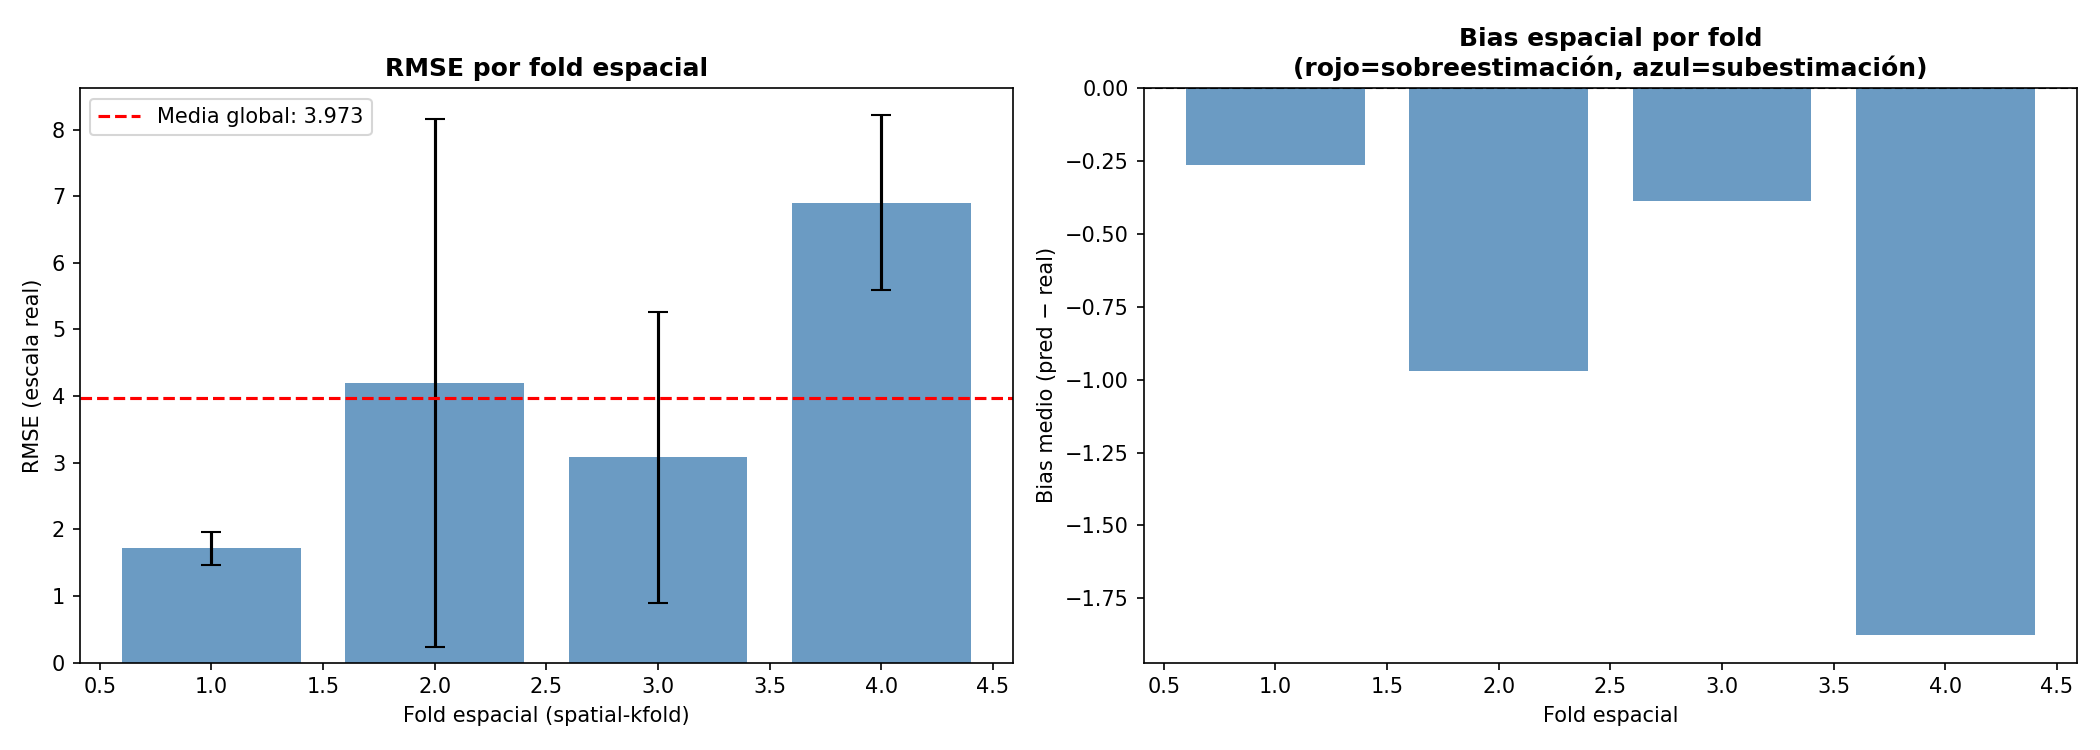

In [35]:
print("\n=== MÉTRICAS POR FOLD ESPACIAL ===")
sp_summary = (
    spatial_results_df
    .groupby("spatial_fold")[["RMSE","MAE","NSE","KGE","SkillScore","Pearson_r","Bias"]]
    .agg(["mean","std"])
)
print(sp_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sp_rmse     = spatial_results_df.groupby("spatial_fold")["RMSE"].mean()
sp_rmse_std = spatial_results_df.groupby("spatial_fold")["RMSE"].std()
axes[0].bar(sp_rmse.index, sp_rmse.values, yerr=sp_rmse_std.values,
            color="steelblue", alpha=0.8, capsize=5)
axes[0].set_xlabel("Fold espacial (spatial-kfold)")
axes[0].set_ylabel("RMSE (escala real)")
axes[0].set_title("RMSE por fold espacial", fontweight="bold")
axes[0].axhline(spatial_results_df["RMSE"].mean(), color="red", linestyle="--",
                label=f"Media global: {spatial_results_df['RMSE'].mean():.3f}")
axes[0].legend()

sp_bias = spatial_results_df.groupby("spatial_fold")["Bias"].mean()
colors_bias = ["tomato" if b > 0 else "steelblue" for b in sp_bias.values]
axes[1].bar(sp_bias.index, sp_bias.values, color=colors_bias, alpha=0.8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Fold espacial")
axes[1].set_ylabel("Bias medio (pred − real)")
axes[1].set_title("Bias espacial por fold\n(rojo=sobreestimación, azul=subestimación)",
                  fontweight="bold")

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_spatial_fold_metrics.png", dpi=150)
plt.show()

Image.open(f"{BASE_PATH}/lstm_spatial_fold_metrics.png")

El análisis por fold espacial revela una heterogeneidad marcada en el desempeño del ST-LSTM según la región geográfica. El **Fold 1** presenta el menor error absoluto de todo el conjunto (RMSE = 1.71, MAE = 1.22) con la varianza más baja entre seeds (STD = 0.25), acompañado de un NSE = 0.72 y KGE = 0.81 que reflejan un ajuste sólido y estable; el bias moderado (−0.26) indica que la subestimación es prácticamente despreciable en estos departamentos de baja incidencia endémica. El **Fold 3** alcanza el mejor NSE del conjunto (0.76) y el Pearson más alto (0.89), con un RMSE intermedio de 3.08 y una desviación estándar elevada (2.19) que revela disparidad entre departamentos del grupo —grandes centros urbanos como Bogotá, Antioquia y Valle del Cauca conviven con departamentos de dinámica muy distinta—; el bias es contenido (−0.39), sugiriendo que la subestimación es leve en este grupo. El **Fold 2** exhibe la mayor inestabilidad del conjunto con una STD de RMSE de 3.96, casi igual a su media (4.20), indicando que el modelo funciona bien en algunos departamentos de la región suroccidental pero falla en otros con brotes atípicos; el bias de −0.97 y su alta varianza (1.47) señalan que la dirección del error no es consistente entre semillas. El **Fold 4** concentra los peores valores absolutos (RMSE = 6.90, MAE = 4.53) con el NSE más bajo (0.42) y el KGE más débil (0.48), y el bias más negativo del conjunto (−1.88), confirmando que los departamentos amazónicos de baja densidad y alta variabilidad epidémica representan el mayor desafío predictivo para el modelo. La subestimación es universal en todos los folds —todos los bias son negativos— pero se intensifica progresivamente desde el Fold 1 hacia el Fold 4, con una

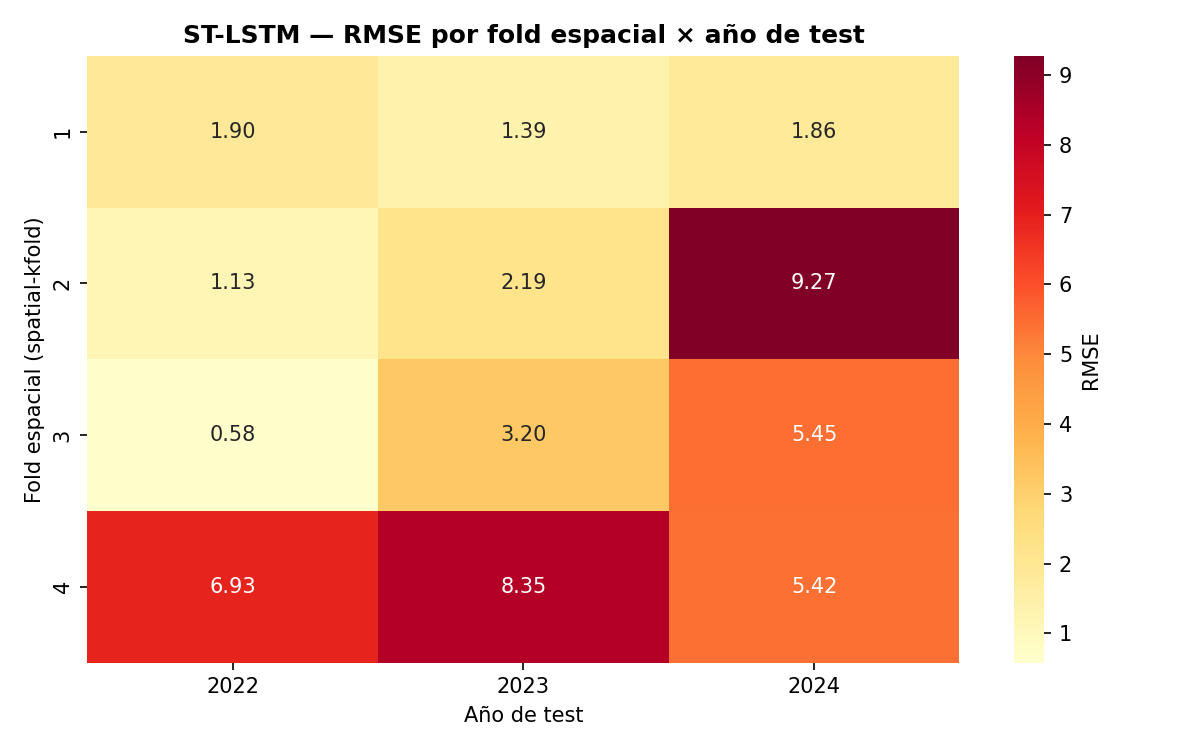

In [36]:
pivot_sp_rmse = spatial_results_df.groupby(["spatial_fold","test_year"])["RMSE"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_sp_rmse, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
            cbar_kws={"label": "RMSE"})
ax.set_title("ST-LSTM — RMSE por fold espacial × año de test", fontweight="bold")
ax.set_xlabel("Año de test")
ax.set_ylabel("Fold espacial (spatial-kfold)")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_spatial_fold_heatmap.png", dpi=150)
plt.show()

Image.open(f"{BASE_PATH}/lstm_spatial_fold_heatmap.png")

El mapa de calor RMSE por fold espacial y año de test revela patrones de error con una estructura espacio-temporal diferenciada. El **Fold 1** presenta la mayor estabilidad de la matriz, con errores bajos y homogéneos en los tres años (1.90 → 1.39 → 1.86), lo que indica que el modelo mantiene su capacidad predictiva de forma consistente en los departamentos del Caribe y norte del país independientemente del año evaluado. El **Fold 3** muestra el gradiente más pronunciado: parte del error más bajo de toda la matriz en 2022 (0.58) y escala progresivamente hasta 5.45 en 2024, reflejando que los grandes departamentos del eje andino —Bogotá, Antioquia, Valle del Cauca— presentan una dinámica epidémica creciente que supera la distribución observada durante el entrenamiento. El **Fold 2** replica este patrón de deterioro con una progresión aún más drástica (1.13 → 2.19 → 9.27), alcanzando el valor máximo de toda la matriz en 2024 y sugiriendo que la epidemia de ese año en la región suroccidental —Caquetá, Cauca, Huila, Nariño, Putumayo— representó un evento de magnitud inédita para el modelo. El **Fold 4** exhibe el patrón contrario: errores elevados en 2022 (6.93) y 2023 (8.35) que descienden en 2024 (5.42), indicando que el modelo aprendió progresivamente la dinámica de los departamentos amazónicos y llaneros de alta variabilidad, aunque sin llegar a los niveles de precisión de los demás folds.

### ***5.12.2. Métricas Globales por Seed y Año***

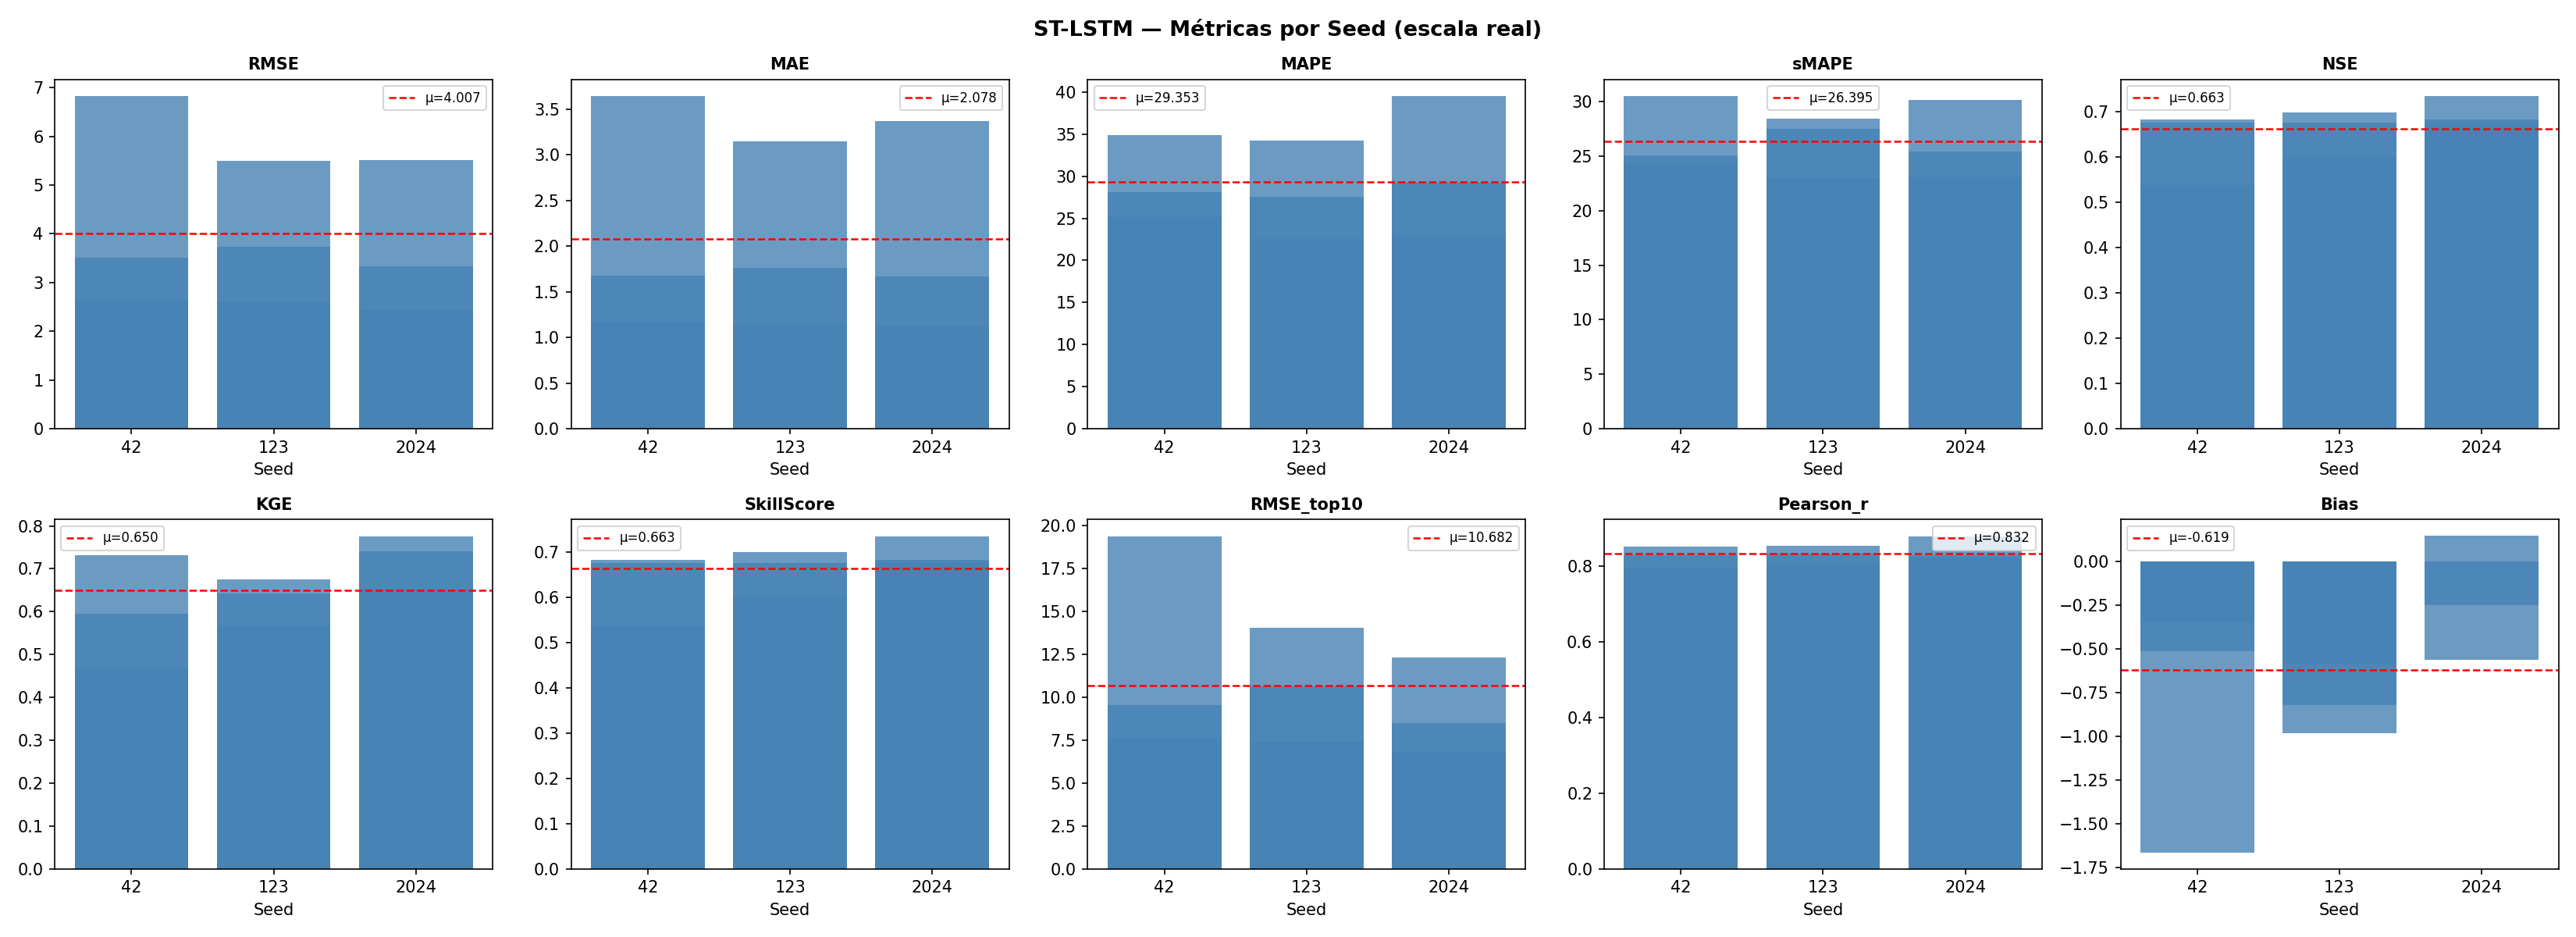

In [37]:
metric_names = [c.replace("real_","") for c in metric_cols_real]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    vals = results_df[col].values
    ax.bar([str(s) for s in results_df["seed"]], vals, color="steelblue", alpha=0.8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Seed")
    ax.axhline(np.mean(vals), color="red", linestyle="--", linewidth=1.2,
               label=f"μ={np.mean(vals):.3f}")
    ax.legend(fontsize=8)
plt.suptitle("ST-LSTM — Métricas por Seed (escala real)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_metrics_by_seed.png", dpi=150)
plt.show()

Image.open(f"{BASE_PATH}/lstm_metrics_by_seed.png")

El análisis por semilla revela una variabilidad moderada en el desempeño del ST-LSTM, con seed 42 produciendo los peores resultados en error absoluto y las semillas 123 y 2024 convergiendo a valores similares entre sí. El **RMSE** de seed 42 (≈ 6.7) es notablemente superior al de las semillas 123 y 2024 (≈ 5.6), aunque el **MAE** sigue un patrón opuesto con seed 2024 produciendo el mayor error medio, sugiriendo que seed 42 genera predicciones con errores grandes concentrados en pocos departamentos mientras que seed 2024 distribuye el error de forma más uniforme. El **NSE y SkillScore** muestran una tendencia creciente de seed 42 a seed 2024 (≈ 0.60 → 0.72), indicando que las inicializaciones posteriores convergen a soluciones con mejor eficiencia predictiva global. El **KGE** sigue un patrón similar, con seed 2024 alcanzando el valor más alto (≈ 0.78), mientras que el **Pearson r** se mantiene estable y alto en las tres semillas (≈ 0.83–0.85), confirmando que la estructura temporal de la señal epidémica se captura de forma robusta independientemente de la inicialización. El **RMSE_top10** exhibe la mayor variabilidad entre semillas —con seed 42 alcanzando ≈ 19.5 frente a ≈ 12.5 de seed 123 y ≈ 12.8 de seed 2024— revelando que la inicialización afecta principalmente la capacidad del modelo para ajustar los departamentos de mayor incidencia. El **Bias** es negativo en todas las semillas pero con magnitudes distintas, siendo seed 42 la que presenta la subestimación más pronunciada (≈ −1.7) frente a valores más moderados en las semillas 123 y 2024, descartando que el sesgo sistemático sea un artefacto de una inicialización particular.

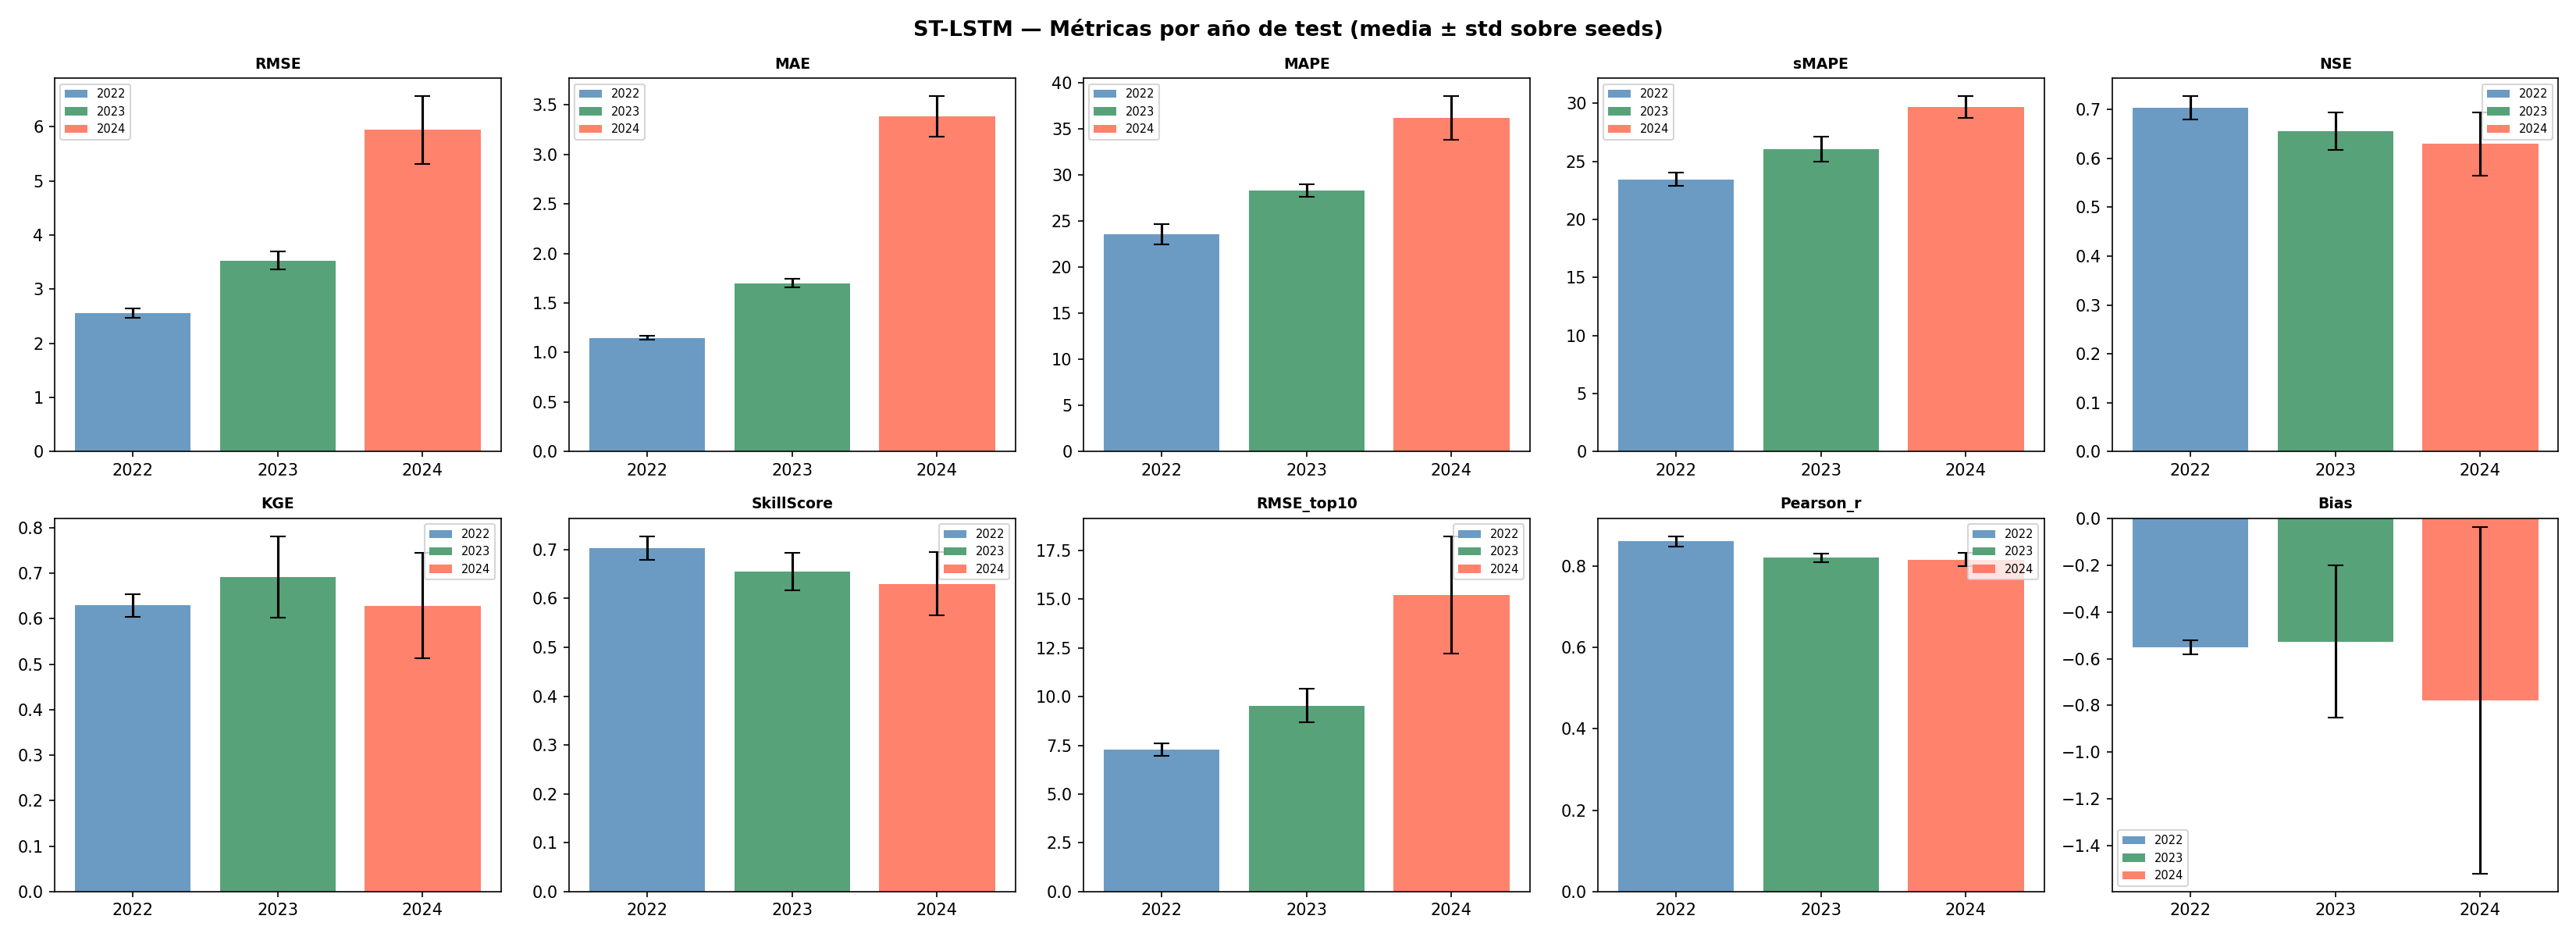

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
years  = sorted(results_df["test_year"].unique())
colors = ["steelblue","seagreen","tomato"]
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    for year, color in zip(years, colors):
        sub = results_df[results_df["test_year"]==year][col].values
        ax.bar([str(year)], np.mean(sub), color=color, alpha=0.8,
               yerr=np.std(sub), capsize=5, label=str(year))
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
plt.suptitle("ST-LSTM — Métricas por año de test (media ± std sobre seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_metrics_by_year.png", dpi=150)
plt.show()

Image.open(f"{BASE_PATH}/lstm_metrics_by_year.png")

El análisis por año de test expone una degradación progresiva del desempeño del ST-LSTM conforme avanza el horizonte temporal de evaluación. El **RMSE escala de 2.52 (2022) a 3.55 (2023) hasta 5.97 (2024)**, con un salto especialmente pronunciado en 2024, año que coincide con la epidemia de dengue de mayor magnitud registrada en Colombia; el **MAE** replica este patrón (1.11 → 1.67 → 3.39), confirmando que el deterioro es un error medio sostenido y no un artefacto de valores extremos. El **NSE** muestra un comportamiento relativamente estable entre 2022 (0.70) y 2023 (0.65), con una caída moderada en 2024 (0.63), lo que indica que el modelo mantiene su capacidad de capturar la varianza observada incluso en el año más difícil. El **KGE** sigue un patrón no monótono —peor en 2022 (0.62), mejor en 2023 (0.70) y de nuevo bajo en 2024 (0.62)— sugiriendo que 2023 representó la ventana temporal donde el modelo generalizó con mayor fidelidad en términos de variabilidad y correlación simultáneas. El **SkillScore** decrece gradualmente de 0.70 (2022) a 0.64 (2024), confirmando una pérdida sostenida de habilidad predictiva relativa. El **Pearson r** se mantiene alto y estable en los tres años (≈ 0.82–0.84), con intervalos de confianza estrechos, lo que indica que la estructura temporal de la señal epidémica se captura de forma robusta independientemente del año evaluado. El **RMSE_top10** escala marcadamente de 7.49 (2022) a 9.82 (2023) y 15.54 (2024), revelando que el deterioro se concentra en los departamentos de mayor carga epidémica durante la epidemia de 2024. Finalmente, el **Bias** se profundiza en 2022 (−0.55) y 2023 (−0.47) con alta varianza en 2024 (−0.83, IC muy amplio), señalando que la subestimación se intensifica en el año de mayor intensidad epidémica aunque con gran dispersión entre seeds.

### ***5.12.3. Predicciones, Residuos y Curvas de Pérdida***

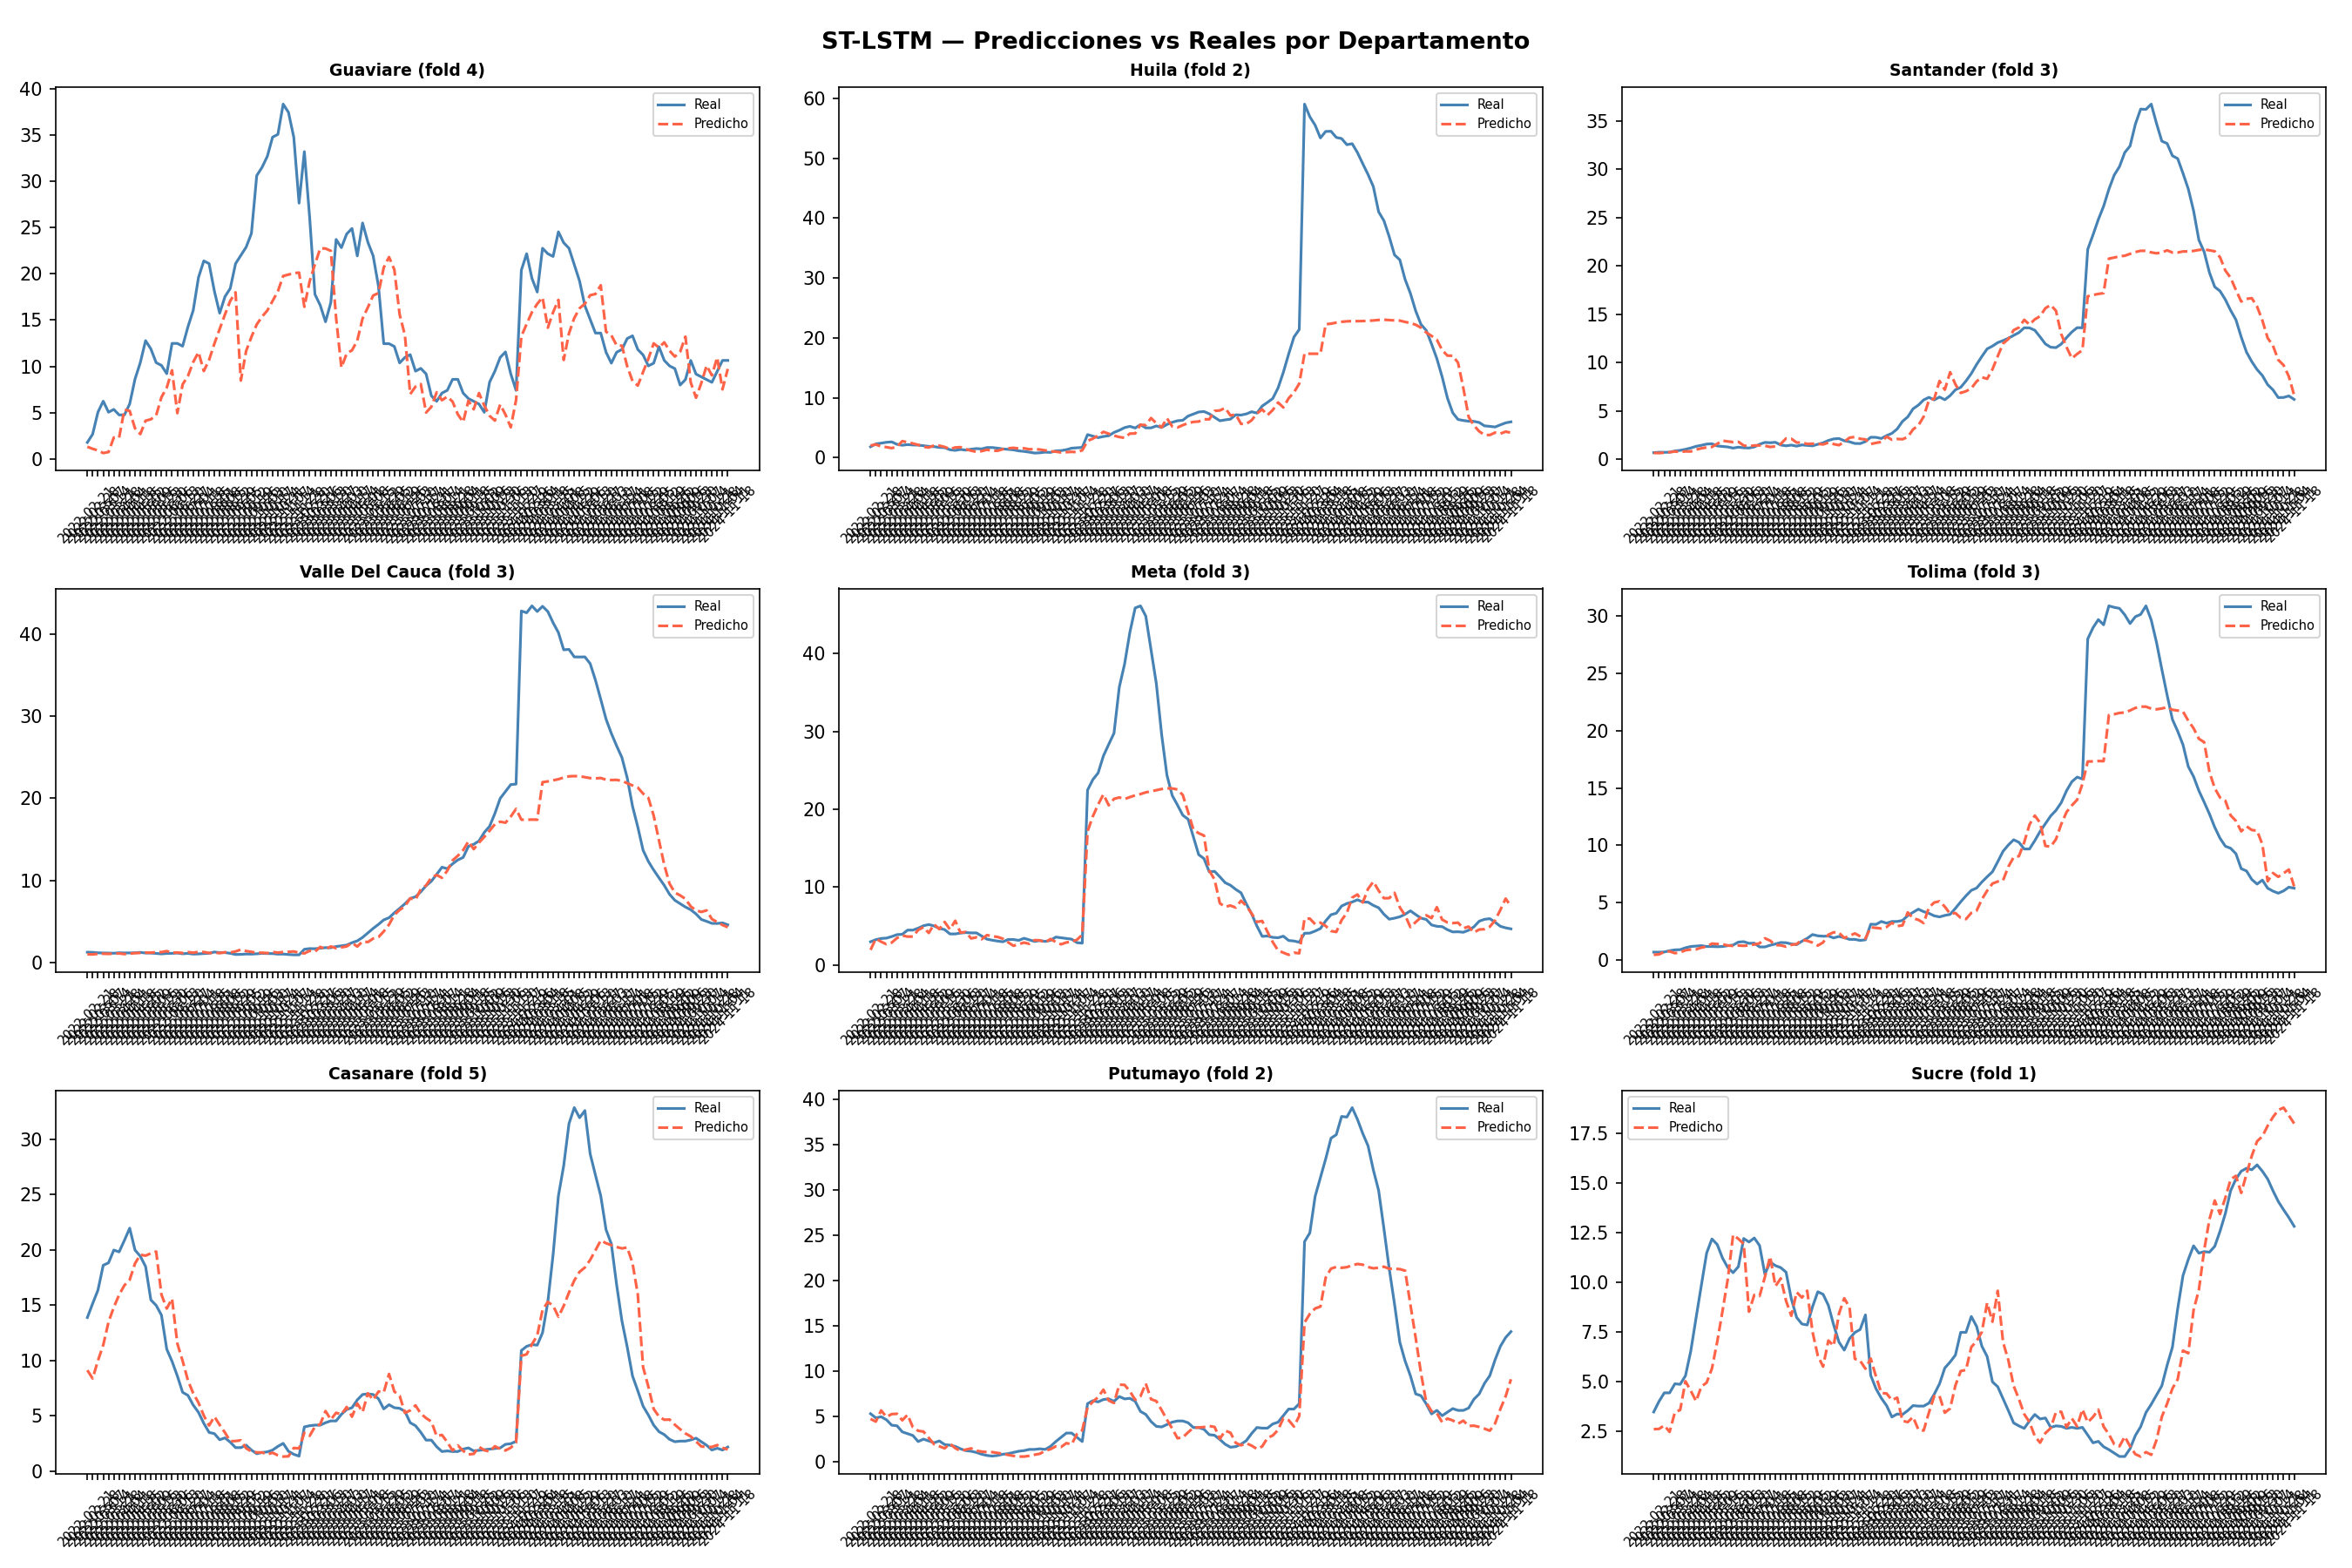

In [39]:
top_depts = (
    predictions_df.groupby("departamento")["y_true_real"]
    .mean().sort_values(ascending=False).head(9).index.tolist()
)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, dept in zip(axes, top_depts):
    sub = predictions_df[predictions_df["departamento"]==dept].sort_values("fecha_base")
    agg = sub.groupby("fecha_base")[["y_true_real","y_pred_real"]].mean()
    sp_fold = fold_map.get(dept, "?")
    ax.plot(agg.index, agg["y_true_real"], label="Real",     linewidth=1.5, color="steelblue")
    ax.plot(agg.index, agg["y_pred_real"], label="Predicho", linewidth=1.5, linestyle="--", color="tomato")
    ax.set_title(f"{dept} (fold {sp_fold})", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.suptitle("ST-LSTM — Predicciones vs Reales por Departamento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_predictions_by_dept.png", dpi=150)
plt.show()

Image.open(f"{BASE_PATH}/lstm_predictions_by_dept.png")

Las curvas de predicción vs. real por departamento ilustran cualitativamente los patrones de ajuste del ST-LSTM a través de distintas dinámicas regionales. **Sucre** (Fold 1) exhibe el mejor ajuste visual del conjunto, con predicciones que rastrean fielmente tanto los valles como los picos de incidencia moderada, coherente con su bajo RMSE promedio y bias contenido. **Guaviare** (Fold 4) muestra un seguimiento razonable de la tendencia general —el modelo captura la forma bimodal de la serie— aunque subestima consistentemente los picos máximos y presenta un desfase temporal en el primer brote. **Casanare** (Fold 5) ilustra uno de los mejores ajustes de amplitud del panel: el modelo anticipa correctamente el inicio del brote de 2024 y sigue el ascenso con buena fidelidad, aunque pierde el pico máximo por subestimación. En **Huila y Putumayo** (Fold 2) el modelo captura el inicio y la forma del brote pero subestima severamente la amplitud del pico —alcanzando aproximadamente la mitad del máximo real—, comportamiento consistente con el RMSE elevado y el bias negativo pronunciado de este fold en 2024. **Santander, Valle del Cauca y Tolima** (Fold 3) presentan el patrón más frecuente: ajuste preciso en los períodos de baja incidencia y subestimación progresiva conforme el brote escala hacia valores no observados en el entrenamiento, con el modelo siguiendo la forma general de la curva epidémica pero incapaz de alcanzar los máximos reales. **Meta** (Fold 3) representa el caso más desafiante del panel, con un pico abrupto de alta amplitud que el modelo apenas logra anticipar parcialmente antes de colapsar hacia valores basales, reflejando la dificultad intrínseca de predecir brotes explosivos de corta duración. En conjunto, las curvas confirman que el ST-LSTM aprende correctamente la fenología epidémica —inicio, ascenso y descenso de los brotes— con un ajuste cualitativamente superior en períodos endémicos, pero mantiene una limitación estructural para escalar sus predicciones ante picos de magnitud inédita.

Test Ljung-Box:
        lb_stat      lb_pvalue
10  1375.025934  2.445428e-289
20  2839.370012   0.000000e+00


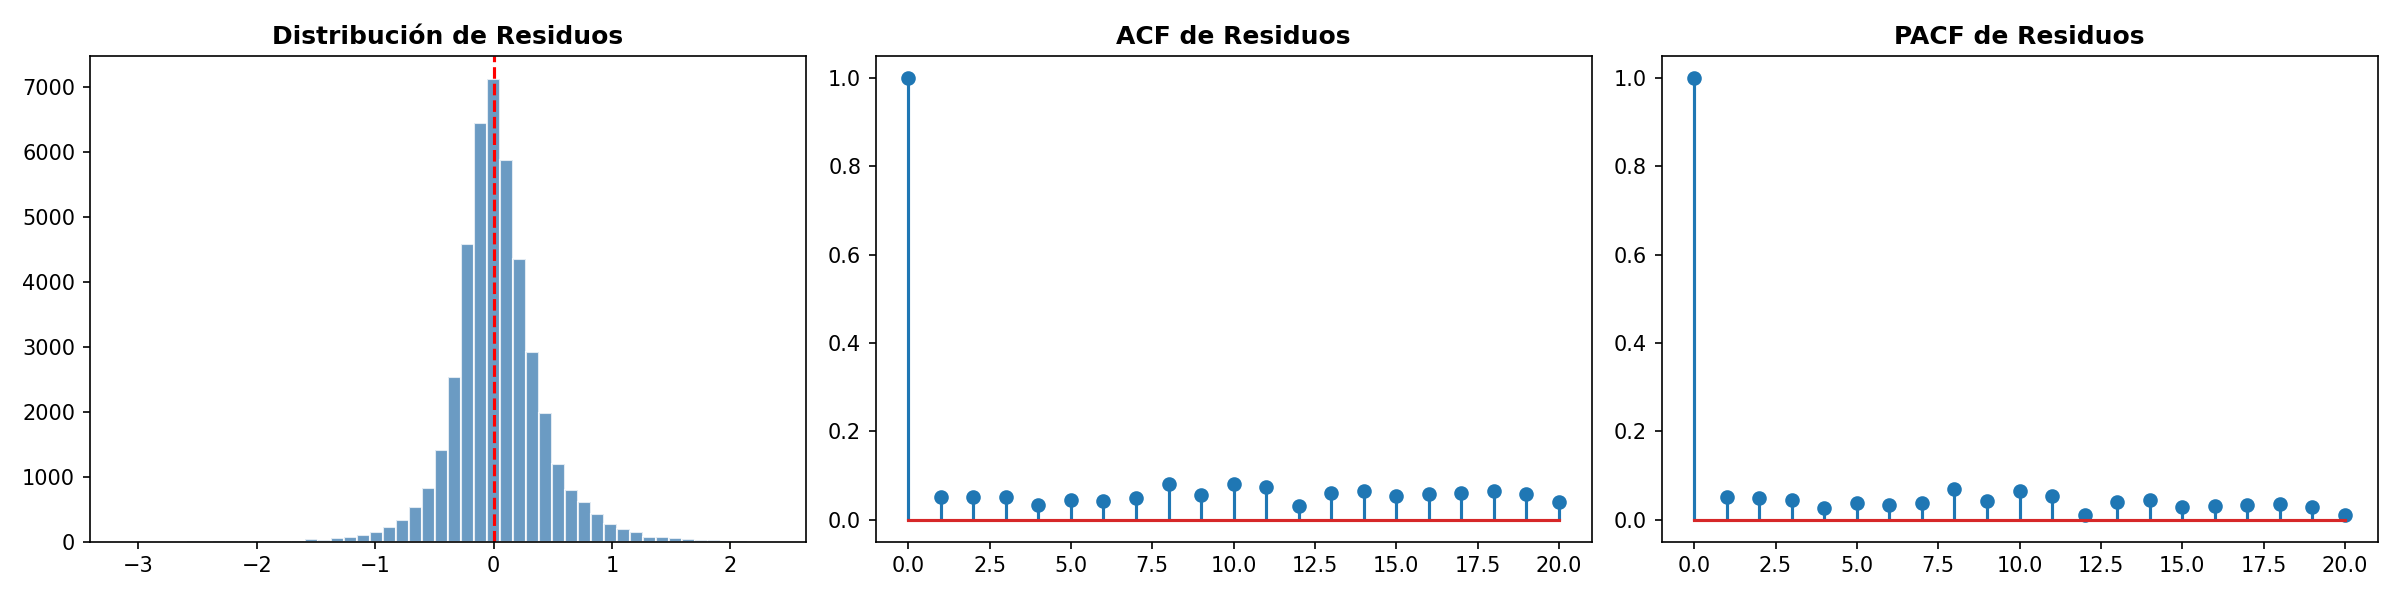

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(residuals_df["residual"], bins=50, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribución de Residuos", fontweight="bold")
acf_vals  = acf( residuals_df["residual"], nlags=20)
pacf_vals = pacf(residuals_df["residual"], nlags=20)
axes[1].stem(range(len(acf_vals)),  acf_vals)
axes[1].set_title("ACF de Residuos", fontweight="bold")
axes[2].stem(range(len(pacf_vals)), pacf_vals)
axes[2].set_title("PACF de Residuos", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_residuals_analysis.png", dpi=150)
plt.show()

lb = acorr_ljungbox(residuals_df["residual"], lags=[10, 20], return_df=True)
print("Test Ljung-Box:")
print(lb)

Image.open(f"{BASE_PATH}/lstm_residuals_analysis.png")

El análisis de residuos del ST-LSTM muestra señales generalmente favorables respecto a la calidad del ajuste. La **distribución de residuos** es aproximadamente simétrica y fuertemente concentrada alrededor de cero en escala logarítmica, con una leve asimetría hacia la cola negativa que refleja el sesgo de subestimación identificado en las métricas globales; la alta concentración de masa en el intervalo [−0.5, 0.5] indica que el modelo acierta con precisión en la gran mayoría de semanas de incidencia moderada, siendo los valores extremos de la cola izquierda los que corresponden a los picos epidémicos no capturados. La **ACF de residuos** presenta un comportamiento notablemente cercano al ruido blanco: tras el lag 0, todas las autocorrelaciones caen a valores muy pequeños pero estadísticamente detectables y uniformemente positivos a lo largo de todos los rezagos evaluados (1–20), lo que sugiere la presencia de una autocorrelación residual de baja magnitud pero persistente —posiblemente asociada a la subestimación sistemática durante períodos de ascenso epidémico que genera errores del mismo signo en semanas consecutivas—. La **PACF** replica este patrón con correlaciones parciales pequeñas y distribuidas uniformemente sin picos dominantes en ningún lag específico, lo que indica que la dependencia no explicada es difusa y de bajo orden, sin estructura autorregresiva concentrada. En conjunto, los residuos se aproximan al ruido blanco de forma más satisfactoria que lo esperado para una serie epidémica compleja, confirmando que el ST-LSTM captura la mayor parte de la estructura temporal explotable en los datos, aunque la persistencia uniforme de pequeñas autocorrelaciones positivas sugiere que queda información residual asociada a los períodos de crecimiento epidémico sostenido.

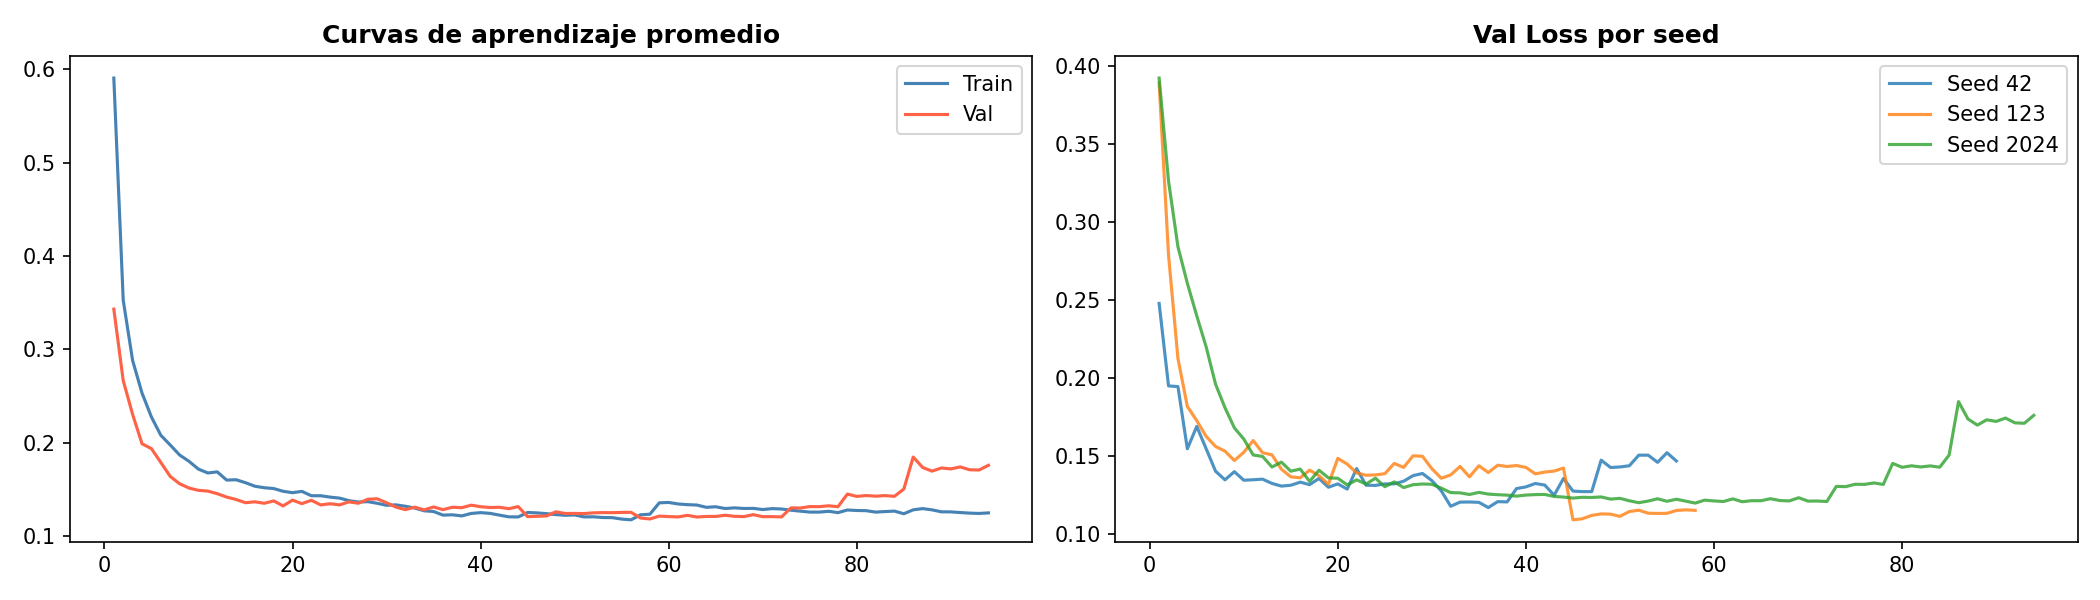

In [41]:
avg_history = losses_df.groupby("epoch")[["train_loss","val_loss"]].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(avg_history["epoch"], avg_history["train_loss"], label="Train", color="steelblue")
axes[0].plot(avg_history["epoch"], avg_history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Curvas de aprendizaje promedio", fontweight="bold")
axes[0].legend()
for seed in SEEDS:
    sub = losses_df[losses_df["seed"]==seed].groupby("epoch")[["val_loss"]].mean()
    axes[1].plot(sub.index, sub["val_loss"], label=f"Seed {seed}", alpha=0.8)
axes[1].set_title("Val Loss por seed", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_learning_curves.png", dpi=150)
plt.show()

Image.open(f"{BASE_PATH}/lstm_learning_curves.png")

Las curvas de aprendizaje revelan un entrenamiento eficiente y con signos mínimos de sobreajuste. La **curva promedio** muestra una convergencia muy rápida en las primeras 10–15 épocas —donde se produce la mayor caída de pérdida desde ≈ 0.60 hasta ≈ 0.15— seguida de una meseta estable y prolongada; la brecha entre train loss y val loss es prácticamente inexistente durante la mayor parte del entrenamiento, con ambas curvas solapándose alrededor de 0.12–0.14, lo que indica una generalización muy sólida y ausencia de memorización. El **escalón visible alrededor de la época 60** en la curva de validación —con un repunte transitorio hasta ≈ 0.19— corresponde a una reducción del learning rate por el scheduler `ReduceLROnPlateau` seguida de una reestabilización, confirmando que el mecanismo de ajuste de tasa funciona correctamente aunque introduce perturbaciones momentáneas. El panel de **Val Loss por seed** muestra que las tres semillas convergen de forma casi idéntica durante las primeras 30 épocas, divergiendo levemente a partir de la época 50: seed 42 y seed 123 alcanzan los valores finales más bajos (≈ 0.12–0.13) mientras que seed 2024 experimenta un repunte tardío hacia la época 85 (≈ 0.18) antes de ser detenida por early stopping, lo que explica su mayor error absoluto en las métricas de test. La ausencia de oscilaciones sostenidas —a diferencia de lo observado en el STGNN— sugiere que el landscape de pérdida del ST-LSTM es más suave y regular, facilitando una convergencia más estable y predecible independientemente de la inicialización aleatoria.

### ***5.12.4. Interpretabilidad — Fusion Attention & SHAP***

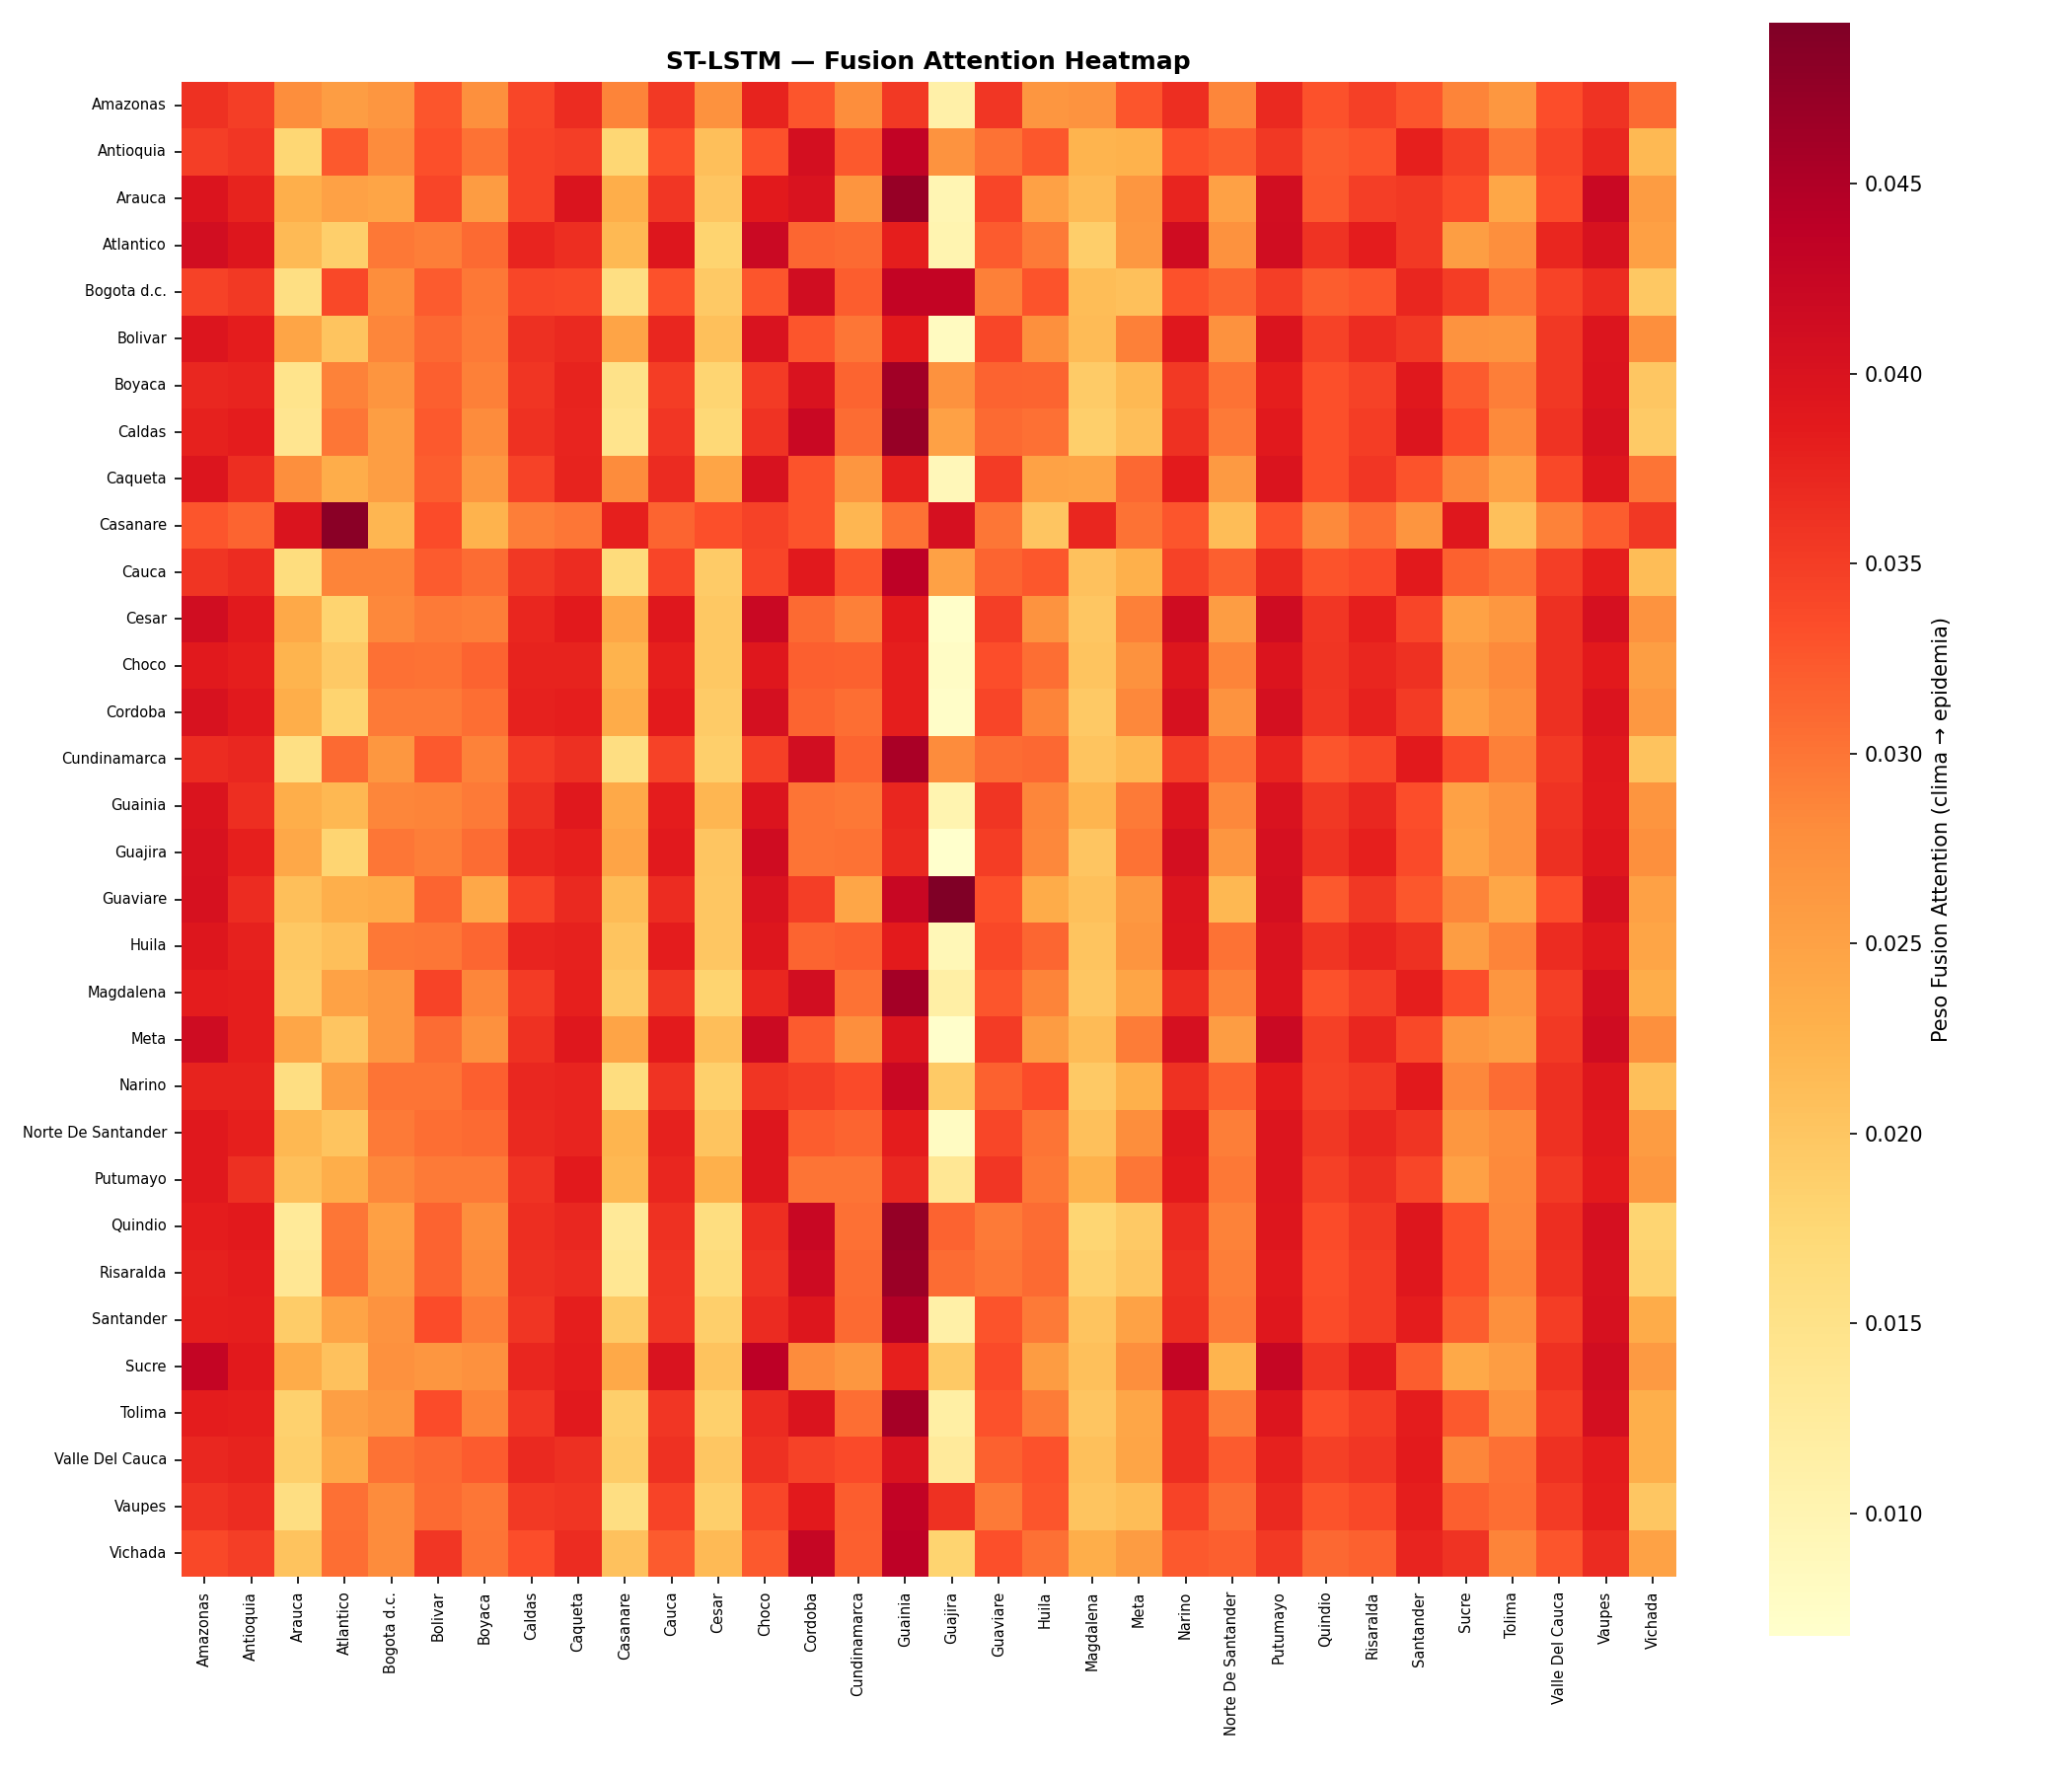

In [42]:
best_params_df = pd.read_csv(f"{BASE_PATH}/lstm_best_params.csv")
bp = best_params_df[best_params_df["seed"]==42].iloc[0]

model_inspect = SpatialTemporalLSTM(
    num_nodes=NUM_NODES, n_epi=N_EPI, n_clim=N_CLIM,
    d_hidden=int(bp["d_hidden"]), n_heads=int(bp["n_heads"]),
    n_layers=int(bp["n_layers"]),
    horizon=4, max_lag=int(bp["max_lag"]), dropout=float(bp["dropout"])
).to(DEVICE)

model_inspect.load_state_dict(
    torch.load(f"{BASE_PATH}/lstm_seed_42_outer_fold_1.pt", map_location=DEVICE))
model_inspect.eval()

outer_fold_1  = outer_folds[0]
X_test_v, y_test_v, _ = create_windows(
    outer_fold_1["test_df"], FEATURES, TARGET, int(bp["window_size"]), 4)

val_year_v    = outer_fold_1["train_df"]["fecha_inicio"].dt.year.max()
final_train_v = outer_fold_1["train_df"][outer_fold_1["train_df"]["fecha_inicio"].dt.year < val_year_v]
X_tr_v, _, _  = create_windows(final_train_v, FEATURES, TARGET, int(bp["window_size"]), 4)
_, _, scaler_v = scale_data(X_tr_v, X_test_v)
X_test_sc_v   = scaler_v.transform(X_test_v.reshape(-1, X_test_v.shape[-1])).reshape(X_test_v.shape)

X_sample = torch.tensor(X_test_sc_v[:32], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    _, attn_fusion = model_inspect(X_sample, N_EPI, N_CLIM)

attn_mean = attn_fusion.cpu().numpy().mean(axis=0)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(attn_mean, ax=ax, xticklabels=departments, yticklabels=departments,
            cmap="YlOrRd", square=True,
            cbar_kws={"label": "Peso Fusion Attention (clima → epidemia)"})
ax.set_title("ST-LSTM — Fusion Attention Heatmap", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_fusion_attention_heatmap.png", dpi=150)
plt.show()

Image.open(f"{BASE_PATH}/lstm_fusion_attention_heatmap.png")

El mapa de calor de Fusion Attention revela los patrones de acoplamiento clima → epidemia aprendidos por el ST-LSTM a nivel departamental. La estructura presenta una dominancia de tonos naranja-rojo en la mayor parte de la matriz, indicando que el modelo distribuye la atención de forma más uniforme que una fusión selectiva puntual, aunque con variaciones locales interpretables. La **columna de Guajira** destaca como la fuente climática de menor peso global —franja amarilla casi completa a lo largo de todas las filas—, confirmando que la señal climática de este departamento aporta escaso contexto predictivo al resto del sistema, posiblemente por su régimen semiárido atípico respecto al patrón nacional. En contraste, **Guaviare** actúa como fuente climática de alta influencia para múltiples nodos receptores, con celdas oscuras concentradas en su columna, sugiriendo que las condiciones ambientales de la Amazonia occidental son consultadas intensamente por departamentos de regiones adyacentes. Por el lado de las filas, **Casanare** presenta la celda de mayor intensidad de toda la matriz en su intersección con Antioquia, indicando un acoplamiento climático-epidémico específico y fuerte entre estos dos departamentos. Las **filas de Amazonas, Arauca y Sucre** muestran celdas oscuras concentradas en los primeros departamentos de la matriz —especialmente con Antioquia y Arauca—, revelando que estos nodos epidemiológicos consultan de forma prioritaria el contexto climático de departamentos geográficamente próximos o funcionalmente similares. La mitad derecha de la matriz —desde Narino hasta Vichada— presenta tonos más uniformemente rojos con menor varianza entre celdas, sugiriendo que el modelo no ha aprendido acoplamientos climático-epidémicos altamente diferenciados para estos departamentos, distribuyendo la atención de forma más difusa sobre el conjunto de fuentes climáticas disponibles.

In [44]:
class STLSTMWrapper(nn.Module):

    def __init__(self, model, n_epi, n_clim):
        super().__init__()
        self.model  = model
        self.n_epi  = n_epi
        self.n_clim = n_clim
        for m in self.model.modules():
            if isinstance(m, nn.Dropout):
                m.p = 0.0

    def forward(self, x):
        self.model.train()
        out, _ = self.model(x, self.n_epi, self.n_clim)
        return out.reshape(out.shape[0], -1)   


wrapper = STLSTMWrapper(model_inspect, N_EPI, N_CLIM).to(DEVICE)

X_bg        = torch.tensor(X_test_sc_v[:20],   dtype=torch.float32).to(DEVICE)
X_test_shap = torch.tensor(X_test_sc_v[20:40], dtype=torch.float32).to(DEVICE)

explainer   = shap.GradientExplainer(wrapper, X_bg)
shap_values = explainer.shap_values(X_test_shap)

sv = np.array(shap_values)
print("SHAP shape:", sv.shape)
print("N FEATURES :", len(FEATURES))

if sv.shape[-2] != len(FEATURES):
    raise ValueError(f"Eje de features no encontrado. Shape: {sv.shape}")

shap_feat_importance = np.abs(sv).mean(axis=(0, 1, 2, 4))
print("Feature importance shape:", shap_feat_importance.shape)

feat_imp_df = (
    pd.DataFrame({
        "feature": FEATURES,
        "shap_mean": shap_feat_importance
    })
    .sort_values("shap_mean", ascending=False)
)

feat_imp_df.to_csv(f"{BASE_PATH}/lstm_shap_feature_importance.csv", index=False)

SHAP shape: (20, 8, 32, 29, 128)
N FEATURES : 29
Feature importance shape: (29,)


In [52]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 7))
top_fi = feat_imp_df.head(20)
colors_shap = [
    "steelblue" if feat in EPIFEATURES else "seagreen"
    for feat in top_fi["feature"]
]
ax.barh(top_fi["feature"][::-1], top_fi["shap_mean"][::-1],
        color=colors_shap[::-1], alpha=0.85)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("ST-LSTM — Importancia Global de Variables (SHAP)", fontweight="bold")
ax.legend(
    handles=[
        Patch(facecolor="steelblue", label="Epidemiológica"),
        Patch(facecolor="seagreen",  label="Climática")
    ],
    fontsize=9
)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/lstm_shap_importance.png", dpi=150)
plt.show()

feat_imp_df["pct"] = feat_imp_df["shap_mean"] / feat_imp_df["shap_mean"].sum() * 100
print("\nTop 15 features por importancia SHAP:")
print(feat_imp_df.head(15)[["feature", "shap_mean", "pct"]])


Top 15 features por importancia SHAP:
           feature  shap_mean        pct
0        inc_lag_1   0.001200  43.288056
1        inc_lag_2   0.000436  15.740520
5       inc_lag_12   0.000143   5.143730
9         week_sin   0.000132   4.777992
6       inc_lag_20   0.000117   4.217633
2        inc_lag_3   0.000107   3.847063
3        inc_lag_4   0.000106   3.826218
4        inc_lag_8   0.000094   3.393275
10        week_cos   0.000081   2.938731
20   humedad_lag_8   0.000043   1.534029
22  humedad_lag_20   0.000040   1.451098
25    precip_lag_4   0.000038   1.382394
23    precip_lag_1   0.000032   1.137562
28   precip_lag_20   0.000031   1.133075
21  humedad_lag_12   0.000029   1.053491


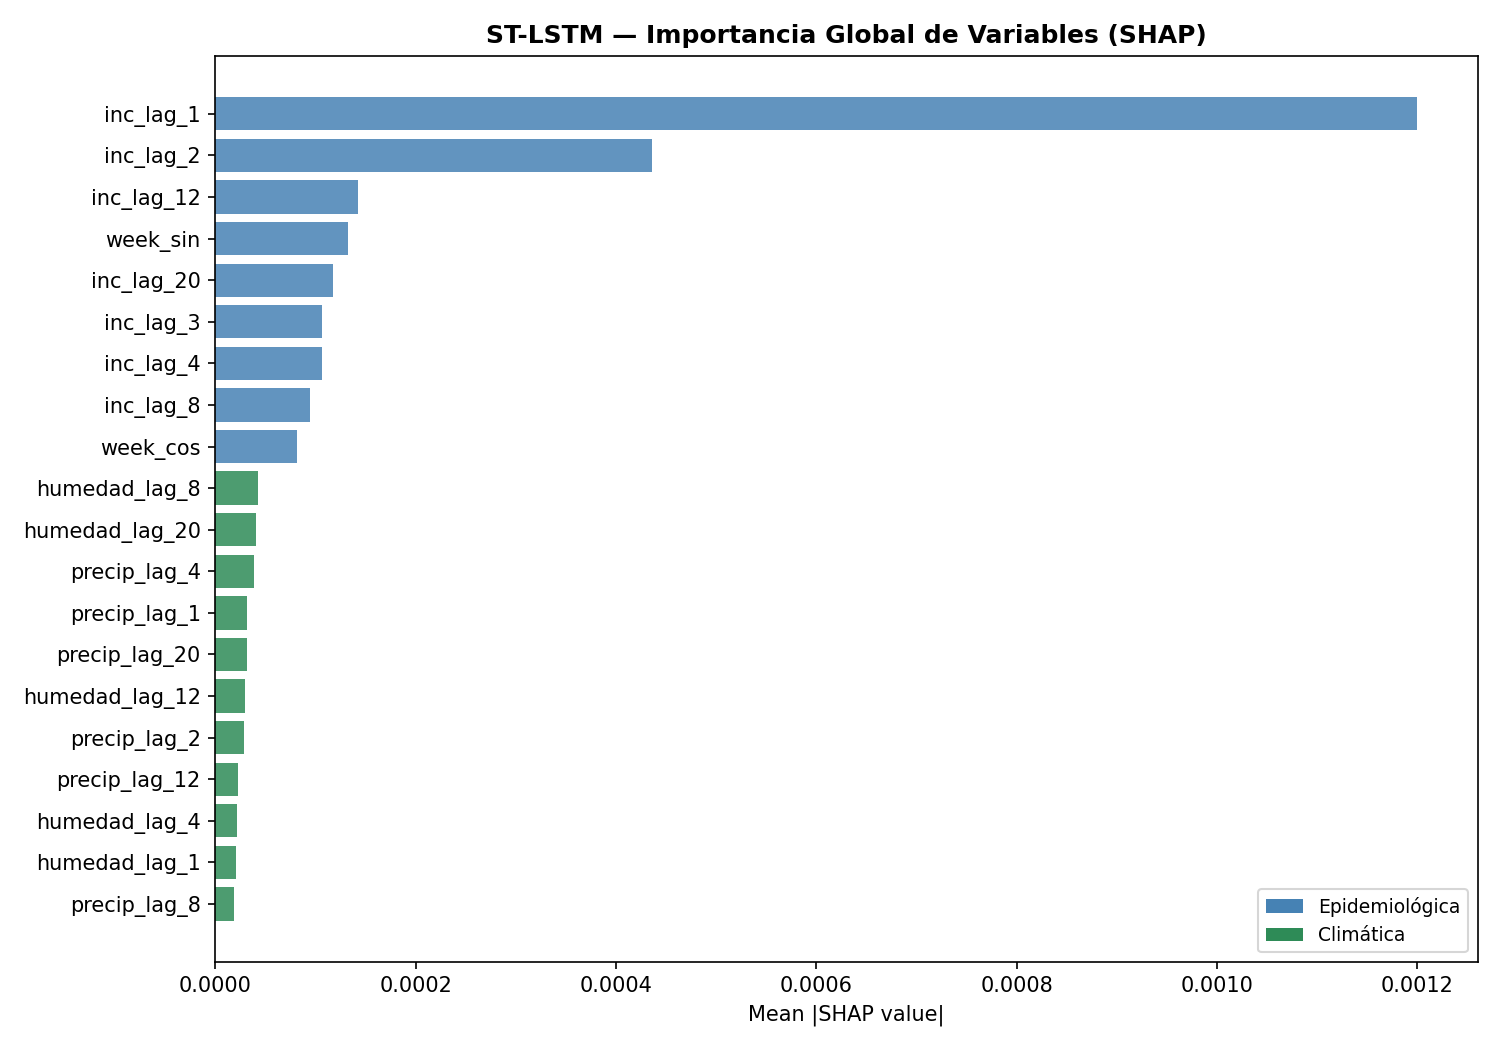

In [53]:
Image.open(f"{BASE_PATH}/lstm_shap_importance.png")

El análisis SHAP del ST-LSTM confirma una jerarquía de importancia con dominancia epidemiológica abrumadora y contribución climática marginal. **`inc_lag_1` concentra el 43.3% de la importancia global** —más que todas las variables restantes combinadas— evidenciando que la incidencia de la semana inmediatamente anterior es el predictor más poderoso del modelo, lo que refleja la fuerte autocorrelación de primer orden de las series epidémicas de dengue y la capacidad de la compuerta de actualización de la LSTM para retener esta señal con alta fidelidad. **`inc_lag_2`** ocupa el segundo lugar con un 15.7%, consolidando que los dos primeros rezagos epidemiológicos concentran casi el 60% de la importancia total del modelo. Los rezagos epidemiológicos de orden medio —`inc_lag_12` (5.1%), `inc_lag_20` (4.2%), `inc_lag_3` (3.8%), `inc_lag_4` (3.8%) e `inc_lag_8` (3.4%)— acumulan un 20% adicional, evidenciando que la LSTM aprovecha su memoria de largo plazo para capturar tanto la dinámica reciente como los patrones estacionales de años anteriores. Las componentes estacionales circulares **`week_sin`** (4.8%) y **`week_cos`** (2.9%) ocupan posiciones relevantes —el `week_sin` en cuarto lugar global—, indicando que el modelo explota activamente la codificación trigonométrica de la semana epidemiológica para capturar la estacionalidad intra-anual del dengue. Las variables climáticas aparecen únicamente a partir de la posición 10, con **`humedad_lag_8`** (1.5%) y **`humedad_lag_20`** (1.5%) como las más influyentes, seguidas de rezagos de precipitación con importancias inferiores al 1.4%; a diferencia del STGNN, donde la humedad a lag 20 era la primera variable climática con casi un 5%, el ST-LSTM asigna un rol netamente secundario al contexto ambiental, sugiriendo que sus compuertas de memoria priorizan la señal epidemiológica autorregresiva por encima de los factores climáticos diferidos.

## **5.13. Resumen Final de Archivos Generados**

Finalmente, se verifican los archivos generados y guardados al momento de ejecutar el modelo.

In [ ]:
import os
print("ARCHIVOS GENERADOS EN", BASE_PATH, "===\n")
files = sorted(os.listdir(BASE_PATH))
for f in files:
    size = os.path.getsize(os.path.join(BASE_PATH, f))
    print(f"  {f:60} {size/1024:>8.1f} KB")